In [1]:
import sys, os, argparse
sys.path.append(os.path.abspath(".."))

import numpy as np
import torch
import torch.multiprocessing as mp
from tqdm import tqdm

import grid_pkg
import controller_pkg
import controller_utils
import dQPTH
import evals

import os
import itertools
import re

torch.set_default_dtype(torch.double)
torch.set_printoptions(threshold=10000)
NUMPY_SEED = 0
TORCH_SEED = 0
np.random.seed(NUMPY_SEED)
torch.manual_seed(TORCH_SEED)

skipping pardiso


In [2]:
line_data_loc = '../data/case118_line_data.pt'
bus_data_loc = '../data/case118_bus_data.pt'
gen_data_loc = '../data/case118_gen_data.pt'
ptdf_data_loc = '../data/case118_ptdf_data.pt'

bus_with_curt = torch.load(gen_data_loc, weights_only=True)[:,0].int()
num_curt = bus_with_curt.shape[0]
bus_with_batt = torch.tensor([10*i+2 for i in range(12)], dtype=torch.int)
num_batt = bus_with_batt.shape[0]
delta_t = 15

grid = grid_pkg.Grid(bus_with_curt, bus_with_batt, delta_t, line_data_loc, bus_data_loc, gen_data_loc, ptdf_data_loc)
num_agents = 3
nodes_1 = [i for i in range(0, 42)] + [112, 113, 114, 116]
nodes_2 = [i for i in range(42, 69)] 
nodes_3 = [i for i in range(69, 112)] + [115, 117]
partition = [nodes_1, nodes_2, nodes_3]
batt_cost = 100
curt_change_cost = 0.01
curt_net_cost = 1
bus_slack_cost = 1e8
line_slack_cost = 1e2
initial_state = grid.state
# agents = utils.create_split_constraint_agents(grid, num_agents, partition, target_charge, batt_cost, curt_net_cost, curt_change_cost)

power_scale = 4
bus_idx_gap = 10
T = 20
H = 5
file_path = "../data/tauxDeChargeMTJLMA2juillet2018.txt"
train_skew = controller_utils.get_RTE_noise_values(file_path, grid, T, H, power_scale, bus_idx_gap)

naza_dqp_list = controller_utils.create_split_constraint_controllers(grid, num_agents, partition, T, H, batt_cost, curt_change_cost,
                                                        curt_net_cost, bus_slack_cost, line_slack_cost)
naza_dqp_1, naza_dqp_2, naza_dqp_3 = naza_dqp_list
pool = mp.Pool(processes=num_agents)
dqp_eps = 1
settings = dQPTH.build_settings(solve_type="sparse", qp_solver="gurobi", lin_solver="qdldl", warm_start_from_previous=True)
dQP_layer = dQPTH.dQPTH_layer(settings=settings, pool=pool)

# ---- global config used by every checkpoint-loading cell below ----
CHECKPOINT_FOLDER = "../paper_experiments/manual"
control_delay = 1  # set to the control_delay value of the run you want to analyze

/Users/zehanpan/Desktop/College Courses/2026 Summer/rte_project_for_pierre/controller_pkg.py:885: UserWarning: Sparse CSC tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:55.)
  self.csc_scaled_Q = self.scaled_Q.to_sparse_csc()


### Process 2a, ours on test with test skew

In [7]:
param_grid = {
    "torch_seed":       [i for i in range(5)],
    "ps":               [2, 2.4, 2.45, 2.5, 3, 3.5, 4],
    "offset":           [0, 60, 120, 180],
    "epochs":           [120], # old: 120
    "radius":           [0.2],
    "lr":               [0.001], # old: 1e-3
    "optimizer_type":   ["clipped_gd"],
    "lr_schedule":      ["plateau"],
    "patience":         [5], # old: 5
    "batch_size":       [2], # old: 2
    "max_grad_norm":    [30000], # old: 3e4
    "surrogate_mode":   [False, True],
    "perform_tests":    [True]
}
FOLDER_PATH = CHECKPOINT_FOLDER

our_losses_dict = dict()
surrogate_losses_dict = dict()

ps_vals = param_grid["ps"]
offset_vals = param_grid["offset"]
test_skew_mags = [10, 20, 30, 40]
test_seeds = [0, 1, 2]
torch_seeds = param_grid["torch_seed"]
epochs = param_grid["epochs"][0]
lr = param_grid["lr"][0]
radius = param_grid["radius"][0]
optimizer_type = param_grid["optimizer_type"][0]
lr_schedule = param_grid["lr_schedule"][0]
patience = param_grid["patience"][0]
batch_size = param_grid["batch_size"][0]
max_grad_norm = param_grid["max_grad_norm"][0]
surrogate_mode = param_grid["surrogate_mode"][0]
perform_tests = param_grid["perform_tests"][0]
default_lr_decay = 20

for ps, offset, test_skew_mag, torch_seed, test_seed in itertools.product(ps_vals, offset_vals, test_skew_mags, torch_seeds, test_seeds):
    our_losses_dict[(ps,offset,test_skew_mag,torch_seed,test_seed)] = torch.zeros(10)
for ps, offset, test_skew_mag, torch_seed, test_seed in itertools.product(ps_vals, offset_vals, [0], torch_seeds, test_seeds):
    our_losses_dict[(ps,offset,test_skew_mag,torch_seed)] = torch.zeros(10)

In [8]:
# Regex to extract numbers from the specific filename format:
# checkpoint_ps1_offset0_test_skew_mag1_epochs40_lr0.0005_torch_seed3.pt
# Note: We match floats for LR and integers for the rest.
surrogate_mode = False
filename_pattern = re.compile(
    r"checkpoint_ps([\d\.]+)_offset(\d+)_epochs(\d+)_lr([\d\.]+)_torch_seed(\d+)_radius([\d\.]+)_perform_tests(?P<tests>True|False)(?:_optimizer_type(?P<optimizer_type>.+?)(?=_lr_schedule|_lr_decay_step|_patience|_batch_size|_max_grad_norm|_surrogate_mode|\.pt))?(?:_lr_schedule(?P<lr_schedule>.+?)(?=_lr_decay_step|_patience|_batch_size|_max_grad_norm|_surrogate_mode|\.pt))?(?:_lr_decay_step(?P<lr_decay_step>\d+))?(?:_patience(?P<patience>\d+))?(?:_batch_size(?P<batch_size>\d+))?(?:_max_grad_norm(?P<max_grad_norm>\d+))?(?:_surrogate_mode(?P<surrogate_mode>True|False))?\.pt"
)

if not os.path.exists(FOLDER_PATH):
    print(f"Error: Directory not found: {FOLDER_PATH}")

files = [f for f in os.listdir(FOLDER_PATH) if f.endswith(".pt")]
print(f"Total files found in directory: {len(files)}")
done = 0
existing_files = set(os.listdir(FOLDER_PATH))
missing_combos = []
names = []
for ps, offset, torch_seed in itertools.product(ps_vals, offset_vals, torch_seeds):
    done += 1
    filename = f"checkpoint_ps{ps}_offset{offset}_epochs{epochs}_lr{lr}_torch_seed{torch_seed}_radius{radius}_perform_tests{perform_tests}_optimizer_type{optimizer_type}_lr_schedule{lr_schedule}_lr_decay_step{default_lr_decay}_patience{patience}_batch_size{batch_size}_max_grad_norm{int(max_grad_norm)}_surrogate_mode{surrogate_mode}_control_delay{control_delay}.pt"

    if filename not in existing_files:
        missing_combos.append((ps, offset, torch_seed))
        print(filename)
        filename = f"checkpoint_ps{ps}_offset{offset}_epochs{epochs}_lr{lr}_torch_seed{(torch_seed-1)}_radius{radius}_perform_tests{perform_tests}_optimizer_type{optimizer_type}_lr_schedule{lr_schedule}_lr_decay_step{default_lr_decay}_patience{patience}_batch_size{batch_size}_max_grad_norm{int(max_grad_norm)}_surrogate_mode{surrogate_mode}_control_delay{control_delay}.pt"

    ckpt = torch.load(f"{FOLDER_PATH}/{filename}")

    for test_seed, test_skew_mag in itertools.product(test_seeds, test_skew_mags):
        our_losses_dict[(ps,offset,test_skew_mag,torch_seed,test_seed)] = ckpt[(test_skew_mag, test_seed)][:,0]
    our_losses_dict[(ps,offset,0,torch_seed)] = ckpt[(0)][:,0]

print(f"missing: {missing_combos}")

Total files found in directory: 22
checkpoint_ps2_offset0_epochs120_lr0.001_torch_seed0_radius0.2_perform_testsTrue_optimizer_typeclipped_gd_lr_scheduleplateau_lr_decay_step20_patience5_batch_size2_max_grad_norm30000_surrogate_modeFalse_control_delay1.pt


FileNotFoundError: [Errno 2] No such file or directory: '../paper_experiments/manual/checkpoint_ps2_offset0_epochs120_lr0.001_torch_seed-1_radius0.2_perform_testsTrue_optimizer_typeclipped_gd_lr_scheduleplateau_lr_decay_step20_patience5_batch_size2_max_grad_norm30000_surrogate_modeFalse_control_delay1.pt'

In [5]:
surrogate_mode = True
if not os.path.exists(FOLDER_PATH):
    print(f"Error: Directory not found: {FOLDER_PATH}")

files = [f for f in os.listdir(FOLDER_PATH) if f.endswith(".pt")]
print(f"Total files found in directory: {len(files)}")
done = 0
existing_files = set(os.listdir(FOLDER_PATH))
missing_combos = []
names = []
for ps, offset, torch_seed in itertools.product(ps_vals, offset_vals, torch_seeds):
    done += 1
    filename = f"checkpoint_ps{ps}_offset{offset}_epochs{epochs}_lr{lr}_torch_seed{torch_seed}_radius{radius}_perform_tests{perform_tests}_optimizer_type{optimizer_type}_lr_schedule{lr_schedule}_lr_decay_step{default_lr_decay}_patience{patience}_batch_size{batch_size}_max_grad_norm{int(max_grad_norm)}_surrogate_mode{surrogate_mode}_control_delay{control_delay}.pt"

    if filename not in existing_files:
        missing_combos.append((ps, offset, torch_seed, surrogate_mode))
        filename = f"checkpoint_ps{ps}_offset{offset}_epochs{epochs}_lr{lr}_torch_seed{torch_seed-1}_radius{radius}_perform_tests{perform_tests}_optimizer_type{optimizer_type}_lr_schedule{lr_schedule}_lr_decay_step{default_lr_decay}_patience{patience}_batch_size{batch_size}_max_grad_norm{int(max_grad_norm)}_surrogate_mode{surrogate_mode}_control_delay{control_delay}.pt"

    ckpt = torch.load(f"{FOLDER_PATH}/{filename}")

    for test_seed, test_skew_mag in itertools.product(test_seeds, test_skew_mags):
        surrogate_losses_dict[(ps,offset,test_skew_mag,torch_seed,test_seed)] = ckpt[(test_skew_mag, test_seed)][:,0]
    surrogate_losses_dict[(ps,offset,0,torch_seed)] = ckpt[(0)][:,0]

print(f"missing: {missing_combos}")

Error: Directory not found: 2a


FileNotFoundError: [Errno 2] No such file or directory: '2a'

### Process 2b, optimal on test with test skew

In [6]:
param_grid = {
    "ps":               [2, 2.4, 2.45, 2.5, 3, 3.5, 4],
    "offset":           [i * 60 for i in range(4)],
    "test_skew_mag":    [10, 20, 30, 40],
    "radius":           [0.2]
}
FOLDER_PATH = CHECKPOINT_FOLDER

opt_losses_dict = dict()

ps_vals = param_grid["ps"]
offset_vals = param_grid["offset"]
test_skew_mags = [10, 20, 30, 40]
test_seeds = [0, 1, 2]
epochs = 1
lr = 0.0001
torch_seed = 1
radius = param_grid["radius"][0]
perform_tests = True

for ps, offset, test_skew_mag in itertools.product(ps_vals, offset_vals, test_skew_mags):
    opt_losses_dict[(ps,offset,test_skew_mag,test_seed)] = torch.zeros(10)

In [7]:
# Regex to extract numbers from the specific filename format:
# checkpoint_ps1_offset0_test_skew_mag1_epochs40_lr0.0005_torch_seed3.pt
# Note: We match floats for LR and integers for the rest.
filename_pattern = re.compile(
    r"checkpoint_ps([\d\.]+)_offset(\d+)_epochs(\d+)_lr([\d\.]+)_torch_seed(\d+)_radius([\d\.]+)_perform_tests(?P<tests>True|False)\.pt"
)

if not os.path.exists(FOLDER_PATH):
    print(f"Error: Directory not found: {FOLDER_PATH}")

files = [f for f in os.listdir(FOLDER_PATH) if f.endswith(".pt")]
print(f"Total files found in directory: {len(files)}")
done = 0

existing_files = set(os.listdir(FOLDER_PATH))
missing_combos = []
names = []
for ps, offset, test_skew_mag in itertools.product(ps_vals, offset_vals, test_skew_mags):
    filename = f"checkpoint_ps{ps}_offset{offset}_test_skew_mag{test_skew_mag}_radius{radius}_control_delay{control_delay}.pt"
    if filename not in existing_files:
        missing_combos.append((ps, offset, test_skew_mag))
    else:
        ckpt = torch.load(f"{FOLDER_PATH}/{filename}")
    for test_seed in test_seeds:
        try:
            opt_losses_dict[(ps,offset,test_skew_mag,test_seed)] = ckpt[(test_seed, "optimal")][:,0]
        except Exception as e:
            print(f"key error {e} for ps {ps} offset {offset} tsm {test_skew_mag} test_seed {test_seed}")
            print(ckpt.keys())
            raise ValueError
        done += 1

print(missing_combos)

Total files found in directory: 112
[]


### Process 2c, decentralized on test with test skew

In [8]:
param_grid = {
    "ps":               [2, 2.4, 2.45, 2.5, 3, 3.5, 4],
    "offset":           [i * 60 for i in range(4)],
    "test_skew_mag":    [10, 20, 30, 40],
    "radius":           [0.2]
}
FOLDER_PATH = CHECKPOINT_FOLDER

dec_losses_dict = dict()

ps_vals = param_grid["ps"]
offset_vals = param_grid["offset"]
test_skew_mags = param_grid["test_skew_mag"]
test_seeds = [0, 1, 2]
epochs = 1
lr = 0.0001
torch_seed = 1
radius = param_grid["radius"][0]
perform_tests = True

for ps, offset, test_skew_mag, test_seed in itertools.product(ps_vals, offset_vals, test_skew_mags, test_seeds):
    dec_losses_dict[(ps,offset,test_skew_mag,test_seed)] = torch.zeros(10)

In [9]:
# Regex to extract numbers from the specific filename format:
# checkpoint_ps1_offset0_test_skew_mag1_epochs40_lr0.0005_torch_seed3.pt
# Note: We match floats for LR and integers for the rest.
filename_pattern = re.compile(
    r"checkpoint_ps([\d\.]+)_offset(\d+)_epochs(\d+)_lr([\d\.]+)_torch_seed(\d+)_radius([\d\.]+)_perform_tests(?P<tests>True|False)\.pt"
)

if not os.path.exists(FOLDER_PATH):
    print(f"Error: Directory not found: {FOLDER_PATH}")

files = [f for f in os.listdir(FOLDER_PATH) if f.endswith(".pt")]
print(f"Total files found in directory: {len(files)}")
done = 0

existing_files = set(os.listdir(FOLDER_PATH))
missing_combos = []
names = []
for ps, offset, test_skew_mag in itertools.product(ps_vals, offset_vals, test_skew_mags):
    filename = f"checkpoint_ps{ps}_offset{offset}_test_skew_mag{test_skew_mag}_radius{radius}_control_delay{control_delay}.pt"
    if filename not in existing_files:
        missing_combos.append((ps, offset, test_skew_mag, torch_seed))
    else:
        ckpt = torch.load(f"{FOLDER_PATH}/{filename}")

    for test_seed in test_seeds:
        # print(ps,offset,test_skew_mag,ts,torch.max(ckpt[(ts,"optimal")]))
        try:
            dec_losses_dict[(ps,offset,test_skew_mag,test_seed)] = ckpt[(test_seed, "base")][:,0]
        except Exception as e:
            print(ckpt.keys())
            print(FOLDER_PATH, filename)
            raise ValueError
        done += 1
#     else:
#         print(f"Warning: Could not parse filename: {filename}")
print(missing_combos)

Total files found in directory: 112
[]


### Process 1a ours on test

### Process 1b results, opt on test

In [10]:
param_grid = {
    "ps":               [2, 2.4, 2.45, 2.5, 3, 3.5, 4],
    "offset":           [i * 60 for i in range(4)],
    "radius":           [0.2]
}
FOLDER_PATH = CHECKPOINT_FOLDER

ps_vals = param_grid["ps"]
offset_vals = param_grid["offset"]
test_skew_mags = [0]
test_seeds = [0, 1, 2]
epochs = 1
lr = 0.0001
torch_seed = 1
radius = param_grid["radius"][0]
perform_tests = True

if not os.path.exists(FOLDER_PATH):
    print(f"Error: Directory not found: {FOLDER_PATH}")

files = [f for f in os.listdir(FOLDER_PATH) if f.endswith(".pt")]
print(f"Total files found in directory: {len(files)}")
done = 0

existing_files = set(os.listdir(FOLDER_PATH))
missing_combos = []
names = []
for ps, offset, test_skew_mag in itertools.product(ps_vals, offset_vals, test_skew_mags):
    filename = f"checkpoint_ps{ps}_offset{offset}_radius{radius}_control_delay{control_delay}.pt"
    if filename not in existing_files:
        missing_combos.append((ps, offset, test_skew_mag))
    else:
        ckpt = torch.load(f"{FOLDER_PATH}/{filename}")
    for test_skew_mag in test_skew_mags:
        try:
            opt_losses_dict[(ps,offset,test_skew_mag)] = ckpt[("optimal")][:,0]
        except Exception as e:
            print(f"key error {e} for ps {ps} offset {offset} tsm {test_skew_mag}")
            print(ckpt.keys())
            raise ValueError
        done += 1

print(missing_combos)


Total files found in directory: 84
[]


### Process 1c results, dec on test

In [11]:
param_grid = {
    "ps":               [2, 2.4, 2.45, 2.5, 3, 3.5, 4],
    "offset":           [i * 60 for i in range(4)],
    "radius":           [0.2]
}
FOLDER_PATH = CHECKPOINT_FOLDER

ps_vals = param_grid["ps"]
offset_vals = param_grid["offset"]
test_skew_mags = [0]
test_seeds = [0, 1, 2]
epochs = 1
lr = 0.0001
torch_seed = 1
radius = param_grid["radius"][0]
perform_tests = True

if not os.path.exists(FOLDER_PATH):
    print(f"Error: Directory not found: {FOLDER_PATH}")

files = [f for f in os.listdir(FOLDER_PATH) if f.endswith(".pt")]
print(f"Total files found in directory: {len(files)}")
done = 0

existing_files = set(os.listdir(FOLDER_PATH))
missing_combos = []
names = []
for ps, offset, test_skew_mag in itertools.product(ps_vals, offset_vals, test_skew_mags):
    filename = f"checkpoint_ps{ps}_offset{offset}_radius{radius}_control_delay{control_delay}.pt"
    if filename not in existing_files:
        missing_combos.append((ps, offset, test_skew_mag))
    else:
        ckpt = torch.load(f"{FOLDER_PATH}/{filename}")
    for test_skew_mag in test_skew_mags:
        try:
            dec_losses_dict[(ps,offset,test_skew_mag)] = ckpt[("base")][:,0]
        except Exception as e:
            print(f"key error {e} for ps {ps} offset {offset} tsm {test_skew_mag}")
            print(ckpt.keys())
            raise ValueError
        done += 1

print(missing_combos)


Total files found in directory: 28
[]


### plot results

In [12]:
test_skew_mags = [0, 10, 20, 30, 40]
prod = itertools.product(ps_vals, offset_vals, test_skew_mags)
results = dict()
num_torch_seeds = len(torch_seeds)
num_test_seeds = len(test_seeds)
for ps, offset, test_skew_mag in prod:

    if test_skew_mag == 0:
        our_losses_means = torch.zeros(num_torch_seeds)
        our_losses_raw = torch.zeros(num_torch_seeds, 10)
        our_gap_raw = torch.zeros(num_torch_seeds, 10)
        for train_seed in torch_seeds:
            our_losses = our_losses_dict[(ps,offset,test_skew_mag,train_seed)]
            opt_losses = opt_losses_dict[(ps,offset,test_skew_mag)]
            dec_losses = dec_losses_dict[(ps,offset,test_skew_mag)]
            our_losses_means[train_seed] = torch.mean(our_losses)
            our_losses_raw[train_seed] = our_losses
            our_gap_raw[train_seed] = our_losses_dict[(ps,offset,test_skew_mag,train_seed)] / opt_losses
    else:
        our_losses_means = torch.zeros(num_torch_seeds, num_test_seeds)
        our_losses_raw = torch.zeros(num_torch_seeds, num_test_seeds, 10)
        our_gap_raw = torch.zeros(num_torch_seeds, num_test_seeds, 10)
        for train_seed, test_seed in itertools.product(torch_seeds, test_seeds):
            our_losses = our_losses_dict[(ps,offset,test_skew_mag,train_seed,test_seed)]
            opt_losses = opt_losses_dict[(ps,offset,test_skew_mag,test_seed)]
            dec_losses = dec_losses_dict[(ps,offset,test_skew_mag,test_seed)]
            our_losses_means[train_seed,test_seed] = torch.mean(our_losses)
            our_losses_raw[train_seed,test_seed] = our_losses
            our_gap_raw[train_seed,test_seed] = our_losses_dict[(ps,offset,test_skew_mag,train_seed,test_seed)] / opt_losses

    mean_ours = torch.mean(our_losses_raw.flatten())
    std_ours = torch.std(our_losses_raw.flatten())
    mean_opt = torch.mean(opt_losses)
    mean_dec = torch.mean(dec_losses)

    mean_our_gap = torch.mean(our_gap_raw.flatten())
    std_our_gap = torch.std(our_gap_raw.flatten())
    max_our_gap = torch.max(our_gap_raw.flatten())

    subresults = dict()
    # subresults["our_losses_raw"] = our_losses_raw
    subresults["opt_losses"] = opt_losses
    subresults["dec_losses"] = dec_losses
    subresults["mean_ours"] = mean_ours
    subresults["std_ours"] = std_ours
    subresults["mean_opt"] = mean_opt
    # subresults["std_opt"] = std_opt
    subresults["mean_dec"] = mean_dec
    # subresults["std_dec"] = std_dec
    # subresults["our_gap"] = our_gap
    subresults["mean_our_gap"] = mean_our_gap
    subresults["std_our_gap"] = std_our_gap
    subresults["max_our_gap"] = max_our_gap

    results[(ps,offset,test_skew_mag)] = subresults


In [13]:
test_skew_mags = [0, 10, 20, 30, 40]
prod = itertools.product(ps_vals, offset_vals, test_skew_mags)
results = dict()
num_torch_seeds = len(torch_seeds)
num_test_seeds = len(test_seeds)
for ps, offset, test_skew_mag in prod:

    if test_skew_mag == 0:
        our_losses_means = torch.zeros(num_torch_seeds)
        our_losses_raw = torch.zeros(num_torch_seeds, 10)
        our_gap_raw = torch.zeros(num_torch_seeds, 10)
        for train_seed in torch_seeds:
            our_losses = our_losses_dict[(ps,offset,test_skew_mag,train_seed)]
            opt_losses = opt_losses_dict[(ps,offset,test_skew_mag)]
            dec_losses = dec_losses_dict[(ps,offset,test_skew_mag)]
            our_losses_means[train_seed] = torch.mean(our_losses)
            our_losses_raw[train_seed] = our_losses
            our_gap_raw[train_seed] = our_losses_dict[(ps,offset,test_skew_mag,train_seed)] / opt_losses
    else:
        our_losses_means = torch.zeros(num_torch_seeds, num_test_seeds)
        our_losses_raw = torch.zeros(num_torch_seeds, num_test_seeds, 10)
        our_gap_raw = torch.zeros(num_torch_seeds, num_test_seeds, 10)
        for train_seed, test_seed in itertools.product(torch_seeds, test_seeds):
            our_losses = our_losses_dict[(ps,offset,test_skew_mag,train_seed,test_seed)]
            opt_losses = opt_losses_dict[(ps,offset,test_skew_mag,test_seed)]
            dec_losses = dec_losses_dict[(ps,offset,test_skew_mag,test_seed)]
            our_losses_means[train_seed,test_seed] = torch.mean(our_losses)
            our_losses_raw[train_seed,test_seed] = our_losses
            our_gap_raw[train_seed,test_seed] = our_losses_dict[(ps,offset,test_skew_mag,train_seed,test_seed)] / opt_losses

    mean_ours = torch.mean(our_losses_raw.flatten())
    std_ours = torch.std(our_losses_raw.flatten())
    mean_opt = torch.mean(opt_losses)
    mean_dec = torch.mean(dec_losses)

    mean_our_gap = torch.mean(our_gap_raw.flatten())
    std_our_gap = torch.std(our_gap_raw.flatten())
    max_our_gap = torch.max(our_gap_raw.flatten())

    subresults = dict()
    # subresults["our_losses_raw"] = our_losses_raw
    subresults["opt_losses"] = opt_losses
    subresults["dec_losses"] = dec_losses
    subresults["mean_ours"] = mean_ours
    subresults["std_ours"] = std_ours
    subresults["mean_opt"] = mean_opt
    # subresults["std_opt"] = std_opt
    subresults["mean_dec"] = mean_dec
    # subresults["std_dec"] = std_dec
    # subresults["our_gap"] = our_gap
    subresults["mean_our_gap"] = mean_our_gap
    subresults["std_our_gap"] = std_our_gap
    subresults["max_our_gap"] = max_our_gap

    results[(ps,offset,test_skew_mag)] = subresults


/var/folders/zy/zj7yfclj58z15k6w7zfrbtp40000gn/T/ipykernel_17341/392204224.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')
/var/folders/zy/zj7yfclj58z15k6w7zfrbtp40000gn/T/ipykernel_17341/392204224.py:48: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axs.scatter(all_mean_opt, all_mean_dec, c=test_skew_mag_colors[test_skew_mag], s=25, label="DEC", marker="^")


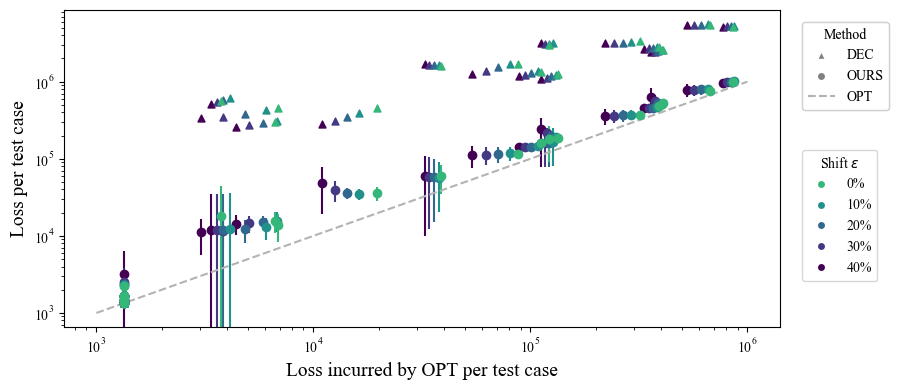

In [14]:
import itertools
from matplotlib.lines import Line2D
import matplotlib.cm as cm
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

method_colors = {"OURS": "green", "DEC": "black"}
skew_values = [0, 10, 20, 30, 40]

# 1. Pick a colormap (e.g., 'viridis', 'plasma', 'coolwarm', or 'YlGnBu')
cmap = cm.get_cmap('viridis') 

# 2. Normalize the values to [0, 1] so they can index the colormap
# This maps 0 -> 0.0 and 40 -> 1.0
norm = plt.Normalize(vmin=min(skew_values), vmax=1.5*max(skew_values))

# 3. Create the dictionary using a comprehension
test_skew_mag_colors = {val: cmap(norm(40-val)) for val in skew_values}

mean_opt_vals = []
ratio_vals = []
fig, axs = plt.subplots(1, figsize=(8,4))
smallest = 1000
identity = torch.logspace(3,6,101)

Y_LIMIT = 9.5


for test_skew_mag in [40, 30, 20, 10, 0]:
    all_mean_opt = list()
    all_mean_ours = list()
    all_std_ours = list()
    all_mean_dec = list()
    for ps, offset in itertools.product([2,2.5,3,3.5,4], offset_vals):
        data = results[(ps,offset,test_skew_mag)]
        mean_ours = data["mean_ours"]
        std_ours = data["std_ours"]
        mean_opt = data["mean_opt"]
        mean_dec = data["mean_dec"]

        if mean_opt > 0:
        
            all_mean_opt.append(mean_opt.item())
            all_mean_ours.append(mean_ours.item())
            all_std_ours.append(std_ours.item())
            all_mean_dec.append(mean_dec.item())

    axs.scatter(all_mean_opt, all_mean_dec, c=test_skew_mag_colors[test_skew_mag], s=25, label="DEC", marker="^")
    axs.errorbar(all_mean_opt, all_mean_ours, all_std_ours, fmt="o", c=test_skew_mag_colors[test_skew_mag], label="OURS")

axs.plot(identity, identity, linestyle="--", label="OPT", color=(0.7, 0.7, 0.7))
handles, labels = axs.get_legend_handles_labels()

# 2. Define your desired order (by label name)
# This is an example; adjust the strings to match your labels exactly
desired_order = ['DEC', 'OURS', 'OPT']

# 3. Create a dictionary to map labels to handles for easy lookup
handle_dict = dict(zip(labels, handles))

# 4. Rebuild the lists in the new order
ordered_handles = [handle_dict[l] for l in desired_order if l in handle_dict]
ordered_labels = [l for l in desired_order if l in handle_dict]
axs.set_xscale('log')
axs.set_yscale('log')
axs.set_xlabel("Loss incurred by OPT per test case", fontsize=14)
axs.set_ylabel("Loss per test case", fontsize=14)
# 1. Get current handles and labels from the axis

method_markers = {"DEC": "^", "OURS": "o"}
opt_handle = Line2D([0], [0], color=(0.7, 0.7, 0.7), linestyle='--', label='OPT')
method_handles = [Line2D([0], [0], marker=m, color='w', markerfacecolor='gray', 
                     linestyle='none', label=f'{k}') for k, m in method_markers.items()]
method_handles.append(opt_handle)
leg1 = fig.legend(handles=method_handles, title="Method", loc='upper left', bbox_to_anchor=(1, 0.95), fontsize=10)
fig.add_artist(leg1)
shift_handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c, 
                         linestyle='none', label=f'{k}%') for k, c in test_skew_mag_colors.items()]
fig.legend(handles=shift_handles, title=r"Shift $\epsilon$", loc='upper left', bbox_to_anchor=(1, 0.63), fontsize=10)
# 5. Re-apply the legend
# axs.legend(ordered_handles, ordered_labels, loc='lower right')

fig.tight_layout()
fig.savefig("Experiment results 1 appendix not lower left.png", dpi=500, bbox_inches='tight')

/var/folders/zy/zj7yfclj58z15k6w7zfrbtp40000gn/T/ipykernel_17341/3459019114.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')
/var/folders/zy/zj7yfclj58z15k6w7zfrbtp40000gn/T/ipykernel_17341/3459019114.py:48: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axs.scatter(all_mean_opt, all_mean_dec, c=test_skew_mag_colors[test_skew_mag], s=25, label="DEC", marker="^")


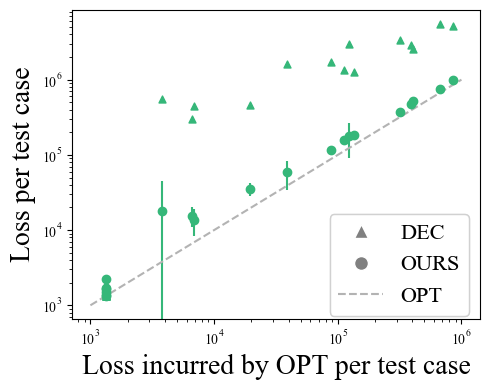

In [15]:
import itertools
from matplotlib.lines import Line2D
import matplotlib.cm as cm
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

method_colors = {"OURS": "green", "DEC": "black"}
skew_values = [0, 10, 20, 30, 40]

# 1. Pick a colormap (e.g., 'viridis', 'plasma', 'coolwarm', or 'YlGnBu')
cmap = cm.get_cmap('viridis') 

# 2. Normalize the values to [0, 1] so they can index the colormap
# This maps 0 -> 0.0 and 40 -> 1.0
norm = plt.Normalize(vmin=min(skew_values), vmax=1.5*max(skew_values))

# 3. Create the dictionary using a comprehension
test_skew_mag_colors = {val: cmap(norm(40-val)) for val in skew_values}

mean_opt_vals = []
ratio_vals = []
fig, axs = plt.subplots(1, figsize=(5,4))
smallest = 1000
identity = torch.logspace(3,6,101)

Y_LIMIT = 9.5


for test_skew_mag in [0]:
    all_mean_opt = list()
    all_mean_ours = list()
    all_std_ours = list()
    all_mean_dec = list()
    for ps, offset in itertools.product([2,2.5,3,3.5,4], offset_vals):
        data = results[(ps,offset,test_skew_mag)]
        mean_ours = data["mean_ours"]
        std_ours = data["std_ours"]
        mean_opt = data["mean_opt"]
        mean_dec = data["mean_dec"]

        if mean_opt > 0:
        
            all_mean_opt.append(mean_opt.item())
            all_mean_ours.append(mean_ours.item())
            all_std_ours.append(std_ours.item())
            all_mean_dec.append(mean_dec.item())

    axs.scatter(all_mean_opt, all_mean_dec, c=test_skew_mag_colors[test_skew_mag], s=25, label="DEC", marker="^")
    axs.errorbar(all_mean_opt, all_mean_ours, all_std_ours, fmt="o", c=test_skew_mag_colors[test_skew_mag], label="OURS")

axs.plot(identity, identity, linestyle="--", label="OPT", color=(0.7, 0.7, 0.7))
handles, labels = axs.get_legend_handles_labels()

# 2. Define your desired order (by label name)
# This is an example; adjust the strings to match your labels exactly
desired_order = ['DEC', 'OURS', 'OPT']

# 3. Create a dictionary to map labels to handles for easy lookup
handle_dict = dict(zip(labels, handles))

# 4. Rebuild the lists in the new order
ordered_handles = [handle_dict[l] for l in desired_order if l in handle_dict]
ordered_labels = [l for l in desired_order if l in handle_dict]
axs.set_xscale('log')
axs.set_yscale('log')
axs.set_xlabel("Loss incurred by OPT per test case", fontsize=20)
axs.set_ylabel("Loss per test case", fontsize=20)
# 1. Get current handles and labels from the axis

method_markers = {"DEC": "^", "OURS": "o"}
opt_handle = Line2D([0], [0], color=(0.7, 0.7, 0.7), linestyle='--', label='OPT')
method_handles = [Line2D([0], [0], marker=m, color='w', markerfacecolor='gray', 
                     linestyle='none', label=f'{k}', markersize=10) for k, m in method_markers.items()]
method_handles.append(opt_handle)
leg1 = fig.legend(handles=method_handles, loc='lower right', bbox_to_anchor=(0.97, 0.17), fontsize=16)
fig.add_artist(leg1)
shift_handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c, 
                         linestyle='none', label=f'{k}%') for k, c in test_skew_mag_colors.items()]
# fig.legend(handles=shift_handles, title=r"Shift $\epsilon$", loc='upper left', bbox_to_anchor=(1, 0.63), fontsize=10)
# 5. Re-apply the legend
# axs.legend(ordered_handles, ordered_labels, loc='lower right')

fig.tight_layout()
fig.savefig("Experiment results 1.png", dpi=500, bbox_inches='tight')

<>:91: SyntaxWarning: invalid escape sequence '\p'
<>:91: SyntaxWarning: invalid escape sequence '\p'
/var/folders/zy/zj7yfclj58z15k6w7zfrbtp40000gn/T/ipykernel_17341/3698762287.py:91: SyntaxWarning: invalid escape sequence '\p'
  fmt="o", c=test_skew_mag_colors[test_skew_mag], label="Mean $\pm$ Std", zorder=1)
/var/folders/zy/zj7yfclj58z15k6w7zfrbtp40000gn/T/ipykernel_17341/3698762287.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')


4.317022326820431
[1.0002381766343142, 1.0178273480278788, 1.1124874859910714, 1.133605955791307, 1.1505013868637253, 1.153546855185362, 1.223187951180326, 1.2385959217514644, 1.2533727463748283, 1.2987091137351456, 1.3104078113030926, 1.3806487919067394, 1.4277484505008307, 1.4488735713680017, 1.5282715509578884, 1.6992314804457334, 1.9645662310456555, 2.050159308660794, 2.435338846914169, 4.001303331265737]
4.317022326820431


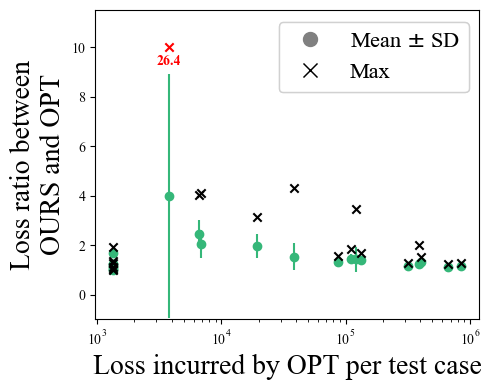

In [16]:
import itertools
from matplotlib.lines import Line2D
import matplotlib.cm as cm
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Linux Libertine'] + plt.rcParams['font.serif']

prod = itertools.product([2,2.5,3,3.5,4], offset_vals, [0]) #[40,30,20,10,0])
method_colors = {"OURS": "green", "DEC": "black"}
skew_values = [0, 10, 20, 30, 40]

# 1. Pick a colormap (e.g., 'viridis', 'plasma', 'coolwarm', or 'YlGnBu')
cmap = cm.get_cmap('viridis')

# 2. Normalize the values to [0, 1] so they can index the colormap
# This maps 0 -> 0.0 and 40 -> 1.0
norm = plt.Normalize(vmin=min(skew_values), vmax=1.5*max(skew_values))

# 3. Create the dictionary using a comprehension
test_skew_mag_colors = {val: cmap(norm(40-val)) for val in skew_values}

mean_opt_vals = []
ratio_vals = []
fig, axs = plt.subplots(1, figsize=(5,4))
smallest = 1000
identity = torch.logspace(3,6,101)

Y_LIMIT = 9.5

# Initialize lists


# Define your cutoff
Y_LIMIT = 10

min_opt = 1.4e3
max_opt = 2.2e4

directions = [1, 0, 0, 1, 1]
idx = 0
for test_skew_mag in [0]:
    all_mean_opt = []
    all_mean_our_gap = []
    all_std_our_gap = []
    normal_max_x = []
    normal_max_y = []
    for ps, offset in itertools.product([2,2.5,3,3.5,4], offset_vals):
        data = results[(ps, offset, test_skew_mag)]

        # Extract values (using .item() for clean floats)
        m_opt = data["mean_opt"].item()
        m_gap = data["mean_our_gap"].item()
        s_gap = data["std_our_gap"].item()
        mx_gap = data["max_our_gap"].item()

        if True:

            # 1. Store main data for the big batch plot
            all_mean_opt.append(m_opt)
            all_mean_our_gap.append(m_gap)
            all_std_our_gap.append(s_gap)

            # 2. Sort the "Max" points: List vs. Immediate Annotation
            if mx_gap < Y_LIMIT:
                # If it fits, save it to the list to scatter later
                normal_max_x.append(m_opt)
                normal_max_y.append(mx_gap)
            else:
                # If it's an outlier, plot the annotation immediately
                # (Annotations can't be batched easily)
                # axs.annotate('', xy=(m_opt, Y_LIMIT), xytext=(m_opt, Y_LIMIT - 1.0),
                #              arrowprops=dict(facecolor='red', edgecolor='red', arrowstyle='->', lw=2))
                direction = directions[idx]
                idx += 1
                if direction == 0:
                    if idx == 2: 
                        axs.text(m_opt * 0.997, Y_LIMIT + 0.7, f'{mx_gap:.1f}',
                                color='red', fontweight='bold', ha='center', va='top',
                                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
                    else:
                        axs.text(m_opt * 1.003, Y_LIMIT + 0.7, f'{mx_gap:.1f}',
                                color='red', fontweight='bold', ha='center', va='top',
                                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
                else:
                    axs.text(m_opt, Y_LIMIT - 0.3, f'{mx_gap:.1f}',
                            color='red', fontweight='bold', ha='center', va='top',
                            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
                axs.scatter(m_opt, Y_LIMIT, color='red', marker='x')

    # 3. Plot all means and error bars at once
    axs.errorbar(all_mean_opt, all_mean_our_gap, all_std_our_gap,
                fmt="o", c=test_skew_mag_colors[test_skew_mag], label="Mean $\pm$ Std", zorder=1)

    # 4. Plot all "normal" max points at once
    print(max(normal_max_y))
    axs.scatter(normal_max_x, normal_max_y, c="black", marker="x",label="Max", zorder=2)
print(sorted(all_mean_our_gap))
print(max(normal_max_y))
# 5. Lock the Y-axis
axs.set_ylim(-1, Y_LIMIT + 1.5)
axs.set_xscale("log")
h_mean = Line2D([0], [0], marker='o', color='w', 
                markerfacecolor='gray', markeredgecolor='gray', 
                linestyle='none', markersize=10, label=r"Mean $\pm$ SD")

# 2. "Max": 'X' with black edge (this was the invisible one)
h_max  = Line2D([0], [0], marker='x', color='w', 
                markeredgecolor='black',  # <--- THIS FIXES THE INVISIBLE X
                linestyle='none', markersize=10, label="Max")
method_handles = [h_mean, h_max]
leg1 = fig.legend(handles=method_handles, loc='upper right', bbox_to_anchor=(0.97, 0.96), fontsize=16)
fig.add_artist(leg1)
shift_handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c,
                         linestyle='none', label=f'{k}%', markersize=10) for k, c in test_skew_mag_colors.items()]
# fig.legend(handles=shift_handles, title=r"Shift $\epsilon$", loc='upper left', bbox_to_anchor=(1, 0.63), fontsize=10)
# Optional: Add legend
# axs.legend(loc='upper right')
axs.set_xlabel("Loss incurred by OPT per test case", fontsize=20)
axs.set_ylabel("Loss ratio between\nOURS and OPT", fontsize=20)
fig.tight_layout()
fig.savefig("Experiment results 2.png", dpi=500, bbox_inches='tight')

/var/folders/zy/zj7yfclj58z15k6w7zfrbtp40000gn/T/ipykernel_17341/640487051.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')
/var/folders/zy/zj7yfclj58z15k6w7zfrbtp40000gn/T/ipykernel_17341/640487051.py:48: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axs.scatter(all_mean_opt, all_mean_dec, c=test_skew_mag_colors[test_skew_mag], s=25, label="DEC", marker="^")


40 [11001.608215078211] [49086.61632045212] [279539.1780732983]
30 [12587.071268983225] [39653.97994960653] [312814.07641255326]
20 [14305.227163339578] [35969.63205677636] [349927.7649566193]
10 [16156.223278192832] [34882.36622145911] [391522.11305959633]
0 [19550.074272029167] [35439.60663598281] [461736.0145983476]


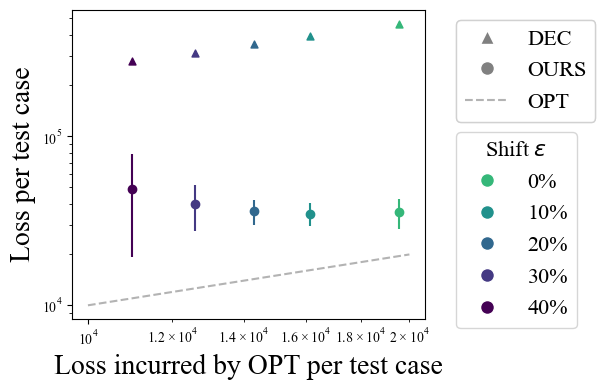

In [17]:
import itertools
from matplotlib.lines import Line2D
import matplotlib.cm as cm
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

method_colors = {"OURS": "green", "DEC": "black"}
skew_values = [0, 10, 20, 30, 40]

# 1. Pick a colormap (e.g., 'viridis', 'plasma', 'coolwarm', or 'YlGnBu')
cmap = cm.get_cmap('viridis') 

# 2. Normalize the values to [0, 1] so they can index the colormap
# This maps 0 -> 0.0 and 40 -> 1.0
norm = plt.Normalize(vmin=min(skew_values), vmax=1.5*max(skew_values))

# 3. Create the dictionary using a comprehension
test_skew_mag_colors = {val: cmap(norm(40-val)) for val in skew_values}

mean_opt_vals = []
ratio_vals = []
fig, axs = plt.subplots(1, figsize=(4.5,4))
smallest = 1000
identity = torch.linspace(1e4,2e4,101)

Y_LIMIT = 9.5


for test_skew_mag in [40, 30, 20, 10, 0]:
    all_mean_opt = list()
    all_mean_ours = list()
    all_std_ours = list()
    all_mean_dec = list()
    for ps, offset in itertools.product([2,2.5,3,3.5,4], offset_vals):
        data = results[(ps,offset,test_skew_mag)]
        mean_ours = data["mean_ours"]
        std_ours = data["std_ours"]
        mean_opt = data["mean_opt"]
        mean_dec = data["mean_dec"]

        if mean_opt > 1e4 and mean_opt < 2e4:
        
            all_mean_opt.append(mean_opt.item())
            all_mean_ours.append(mean_ours.item())
            all_std_ours.append(std_ours.item())
            all_mean_dec.append(mean_dec.item())

    axs.scatter(all_mean_opt, all_mean_dec, c=test_skew_mag_colors[test_skew_mag], s=25, label="DEC", marker="^")
    axs.errorbar(all_mean_opt, all_mean_ours, all_std_ours, fmt="o", c=test_skew_mag_colors[test_skew_mag], label="OURS")
    print(test_skew_mag, all_mean_opt, all_mean_ours, all_mean_dec)
axs.plot(identity, identity, linestyle="--", label="OPT", color=(0.7, 0.7, 0.7))
handles, labels = axs.get_legend_handles_labels()

# 2. Define your desired order (by label name)
# This is an example; adjust the strings to match your labels exactly
desired_order = ['DEC', 'OURS', 'OPT']

# 3. Create a dictionary to map labels to handles for easy lookup
handle_dict = dict(zip(labels, handles))

# 4. Rebuild the lists in the new order
ordered_handles = [handle_dict[l] for l in desired_order if l in handle_dict]
ordered_labels = [l for l in desired_order if l in handle_dict]
axs.set_xscale('log')
axs.set_yscale('log')
axs.set_xlabel("Loss incurred by OPT per test case", fontsize=20)
axs.set_ylabel("Loss per test case", fontsize=20)
# 1. Get current handles and labels from the axis

method_markers = {"DEC": "^", "OURS": "o"}
opt_handle = Line2D([0], [0], color=(0.7, 0.7, 0.7), linestyle='--', label='OPT')
method_handles = [Line2D([0], [0], marker=m, color='w', markerfacecolor='gray', 
                     linestyle='none', label=f'{k}', markersize=10) for k, m in method_markers.items()]
method_handles.append(opt_handle)
leg1 = fig.legend(handles=method_handles, loc='upper left', bbox_to_anchor=(1, 0.965), fontsize=16)
fig.add_artist(leg1)
shift_handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c, 
                         linestyle='none', label=f'{k}%', markersize=10) for k, c in test_skew_mag_colors.items()]
fig.legend(handles=shift_handles, title=r"Shift $\epsilon$", loc='upper left', bbox_to_anchor=(1, 0.685), fontsize=16, title_fontsize=16)
# 5. Re-apply the legend
# axs.legend(ordered_handles, ordered_labels, loc='lower right')

fig.tight_layout()
fig.savefig("Experiment results 3.png", dpi=500, bbox_inches='tight')

In [18]:
test_skew_mags = [0]
mean_dict = dict()
for tsm in test_skew_mags:
    mean_dict[tsm] = list()

included_ps_vals = [2, 2.4, 2.45, 2.5, 3, 3.5, 4]

under_vals = list()
over_vals = list()
other_vals = list()

for ps, offset, test_skew_mag, train_seed in itertools.product(included_ps_vals, offset_vals, test_skew_mags, torch_seeds):
    our_losses = our_losses_dict[(ps,offset,test_skew_mag,train_seed)]
    surrogate_losses = surrogate_losses_dict[(ps,offset,test_skew_mag,train_seed)]
    mean_dict[test_skew_mag].append(torch.mean(surrogate_losses / our_losses))
    if torch.mean(surrogate_losses / our_losses) <= 0.9:
        under_vals.append((ps, offset, test_skew_mag, train_seed))
    elif torch.mean(surrogate_losses / our_losses) >= 1.1:
        over_vals.append((ps, offset, test_skew_mag, train_seed))
    else:
        other_vals.append((ps, offset, test_skew_mag, train_seed))

test_skew_mags = [10, 20, 30, 40]
for tsm in test_skew_mags:
    mean_dict[tsm] = list()

for ps, offset, test_skew_mag, train_seed, test_seed in itertools.product(included_ps_vals, offset_vals, test_skew_mags, torch_seeds, test_seeds):
    our_losses = our_losses_dict[(ps,offset,test_skew_mag,train_seed,test_seed)]
    surrogate_losses = surrogate_losses_dict[(ps,offset,test_skew_mag,train_seed,test_seed)]
    mean_dict[test_skew_mag].append(torch.mean(surrogate_losses / our_losses))
    if torch.mean(surrogate_losses / our_losses) <= 0.9:
        print(ps, offset, test_skew_mag, train_seed, test_seed)

2.5 180 30 4 0
2.5 180 40 1 0
2.5 180 40 4 0


In [27]:
import itertools
from matplotlib.lines import Line2D
import matplotlib.cm as cm
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

<>:13: SyntaxWarning: invalid escape sequence '\%'
<>:13: SyntaxWarning: invalid escape sequence '\%'
/var/folders/zy/zj7yfclj58z15k6w7zfrbtp40000gn/T/ipykernel_17341/2354632303.py:13: SyntaxWarning: invalid escape sequence '\%'
  axs[row,col].text(1.065, 200, f'{pct_over:.1f}\%\nover 1.05',


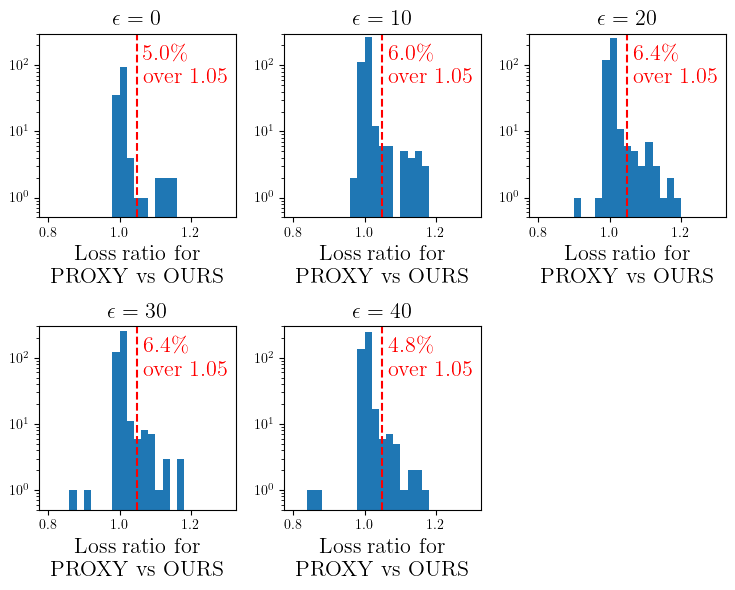

In [56]:
rows = 2
cols = 3
fig, axs = plt.subplots(rows, cols, figsize=(7.5,6))
bins = [0.8 + 0.02 * i for i in range(0,26)]
test_skew_mags = [0, 10, 20, 30, 40]
for i in range(len(test_skew_mags)):
    row = i // 3
    col = i % 3
    data = mean_dict[test_skew_mags[i]]
    pct_over = 100 * sum(v > 1.05 for v in data) / len(data)
    axs[row,col].hist(data, bins=bins)
    axs[row,col].axvline(x=1.05, color='red', linestyle='--', linewidth=1.5)
    axs[row,col].text(1.065, 200, f'{pct_over:.1f}\%\nover 1.05',
                      color='red', fontsize=16, va='top', ha='left')
    axs[row,col].set_title(rf"$ \epsilon={test_skew_mags[i]}$", fontsize=16)
    axs[row,col].set_yscale('log')
    axs[row,col].set_xlabel("Loss ratio for\nPROXY vs OURS", fontsize=16)
    axs[row,col].set_ylim(bottom=0.5, top=300)
axs[1,2].set_visible(False)
fig.tight_layout()
plt.savefig("proxy losses.png", dpi=300)

/var/folders/zy/zj7yfclj58z15k6w7zfrbtp40000gn/T/ipykernel_17341/3591152309.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')
/var/folders/zy/zj7yfclj58z15k6w7zfrbtp40000gn/T/ipykernel_17341/3591152309.py:50: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axs.scatter(all_mean_opt, all_mean_dec, c=test_skew_mag_colors[test_skew_mag], s=25, label="DEC", marker="^")


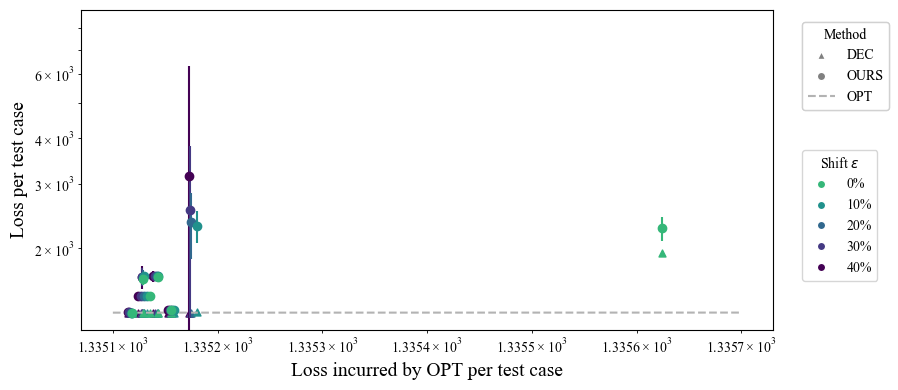

In [22]:
import itertools
from matplotlib.lines import Line2D
import matplotlib.cm as cm
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

method_colors = {"OURS": "green", "DEC": "black"}
skew_values = [0, 10, 20, 30, 40]

# 1. Pick a colormap (e.g., 'viridis', 'plasma', 'coolwarm', or 'YlGnBu')
cmap = cm.get_cmap('viridis')

# 2. Normalize the values to [0, 1] so they can index the colormap
# This maps 0 -> 0.0 and 40 -> 1.0
norm = plt.Normalize(vmin=min(skew_values), vmax=1.5*max(skew_values))

# 3. Create the dictionary using a comprehension
test_skew_mag_colors = {val: cmap(norm(40-val)) for val in skew_values}

mean_opt_vals = []
ratio_vals = []
fig, axs = plt.subplots(1, figsize=(8,4))
smallest = 1000
identity = torch.logspace(3,6,101)

Y_LIMIT = 9.5

identity = torch.linspace(1.3351e3,1.3357e3,101)
axs.plot(identity, identity, linestyle="--", label="OPT", color=(0.7, 0.7, 0.7))

for test_skew_mag in [40, 30, 20, 10, 0]:
    all_mean_opt = list()
    all_mean_ours = list()
    all_std_ours = list()
    all_mean_dec = list()
    for ps, offset in itertools.product([2,2.5,3,3.5,4], offset_vals):
        data = results[(ps,offset,test_skew_mag)]
        mean_ours = data["mean_ours"]
        std_ours = data["std_ours"]
        mean_opt = data["mean_opt"]
        mean_dec = data["mean_dec"]

        if mean_opt <1400:

            all_mean_opt.append(mean_opt.item())
            all_mean_ours.append(mean_ours.item())
            all_std_ours.append(std_ours.item())
            all_mean_dec.append(mean_dec.item())

    axs.scatter(all_mean_opt, all_mean_dec, c=test_skew_mag_colors[test_skew_mag], s=25, label="DEC", marker="^")
    axs.errorbar(all_mean_opt, all_mean_ours, all_std_ours, fmt="o", c=test_skew_mag_colors[test_skew_mag], label="OURS")

handles, labels = axs.get_legend_handles_labels()

# 2. Define your desired order (by label name)
# This is an example; adjust the strings to match your labels exactly
desired_order = ['DEC', 'OURS']

# 3. Create a dictionary to map labels to handles for easy lookup
handle_dict = dict(zip(labels, handles))

# 4. Rebuild the lists in the new order
ordered_handles = [handle_dict[l] for l in desired_order if l in handle_dict]
ordered_labels = [l for l in desired_order if l in handle_dict]
axs.set_xscale('log')
axs.set_yscale('log')
axs.set_ylim(1.2e3)
axs.set_xlabel("Loss incurred by OPT per test case", fontsize=14)
axs.set_ylabel("Loss per test case", fontsize=14)
# 1. Get current handles and labels from the axis

method_markers = {"DEC": "^", "OURS": "o"}
opt_handle = Line2D([0], [0], color=(0.7, 0.7, 0.7), linestyle='--', label='OPT')
method_handles = [Line2D([0], [0], marker=m, color='w', markerfacecolor='gray',
                     linestyle='none', label=f'{k}') for k, m in method_markers.items()]
method_handles.append(opt_handle)
leg1 = fig.legend(handles=method_handles, title="Method", loc='upper left', bbox_to_anchor=(1, 0.95), fontsize=10)
fig.add_artist(leg1)
shift_handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c,
                         linestyle='none', label=f'{k}%') for k, c in test_skew_mag_colors.items()]
fig.legend(handles=shift_handles, title=r"Shift $\epsilon$", loc='upper left', bbox_to_anchor=(1, 0.63), fontsize=10)
# 5. Re-apply the legend
# axs.legend(ordered_handles, ordered_labels, loc='lower right')

fig.tight_layout()
# fig.savefig("Experiment results 1 appendix lower left.png", dpi=500, bbox_inches='tight')

<>:91: SyntaxWarning: invalid escape sequence '\p'
<>:91: SyntaxWarning: invalid escape sequence '\p'
/var/folders/zy/zj7yfclj58z15k6w7zfrbtp40000gn/T/ipykernel_8885/199538350.py:91: SyntaxWarning: invalid escape sequence '\p'
  fmt="o", c=test_skew_mag_colors[test_skew_mag], label="Mean $\pm$ Std", zorder=1)
/var/folders/zy/zj7yfclj58z15k6w7zfrbtp40000gn/T/ipykernel_8885/199538350.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')


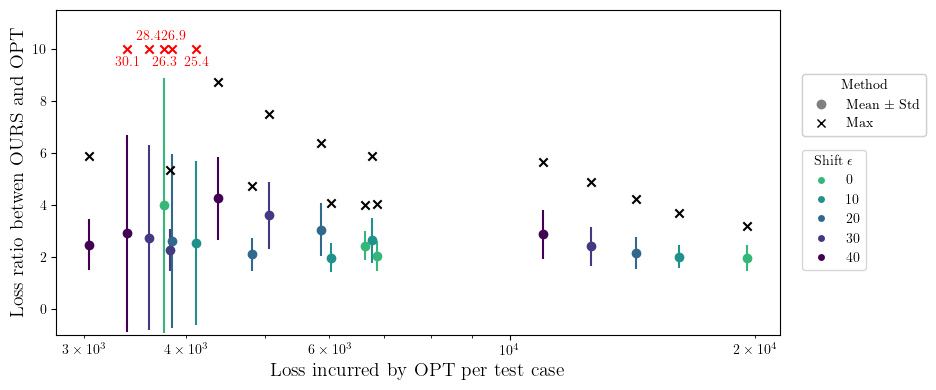

In [48]:
import itertools
from matplotlib.lines import Line2D
import matplotlib.cm as cm
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Linux Libertine'] + plt.rcParams['font.serif']

prod = itertools.product([2,2.5,3,3.5,4], offset_vals, [0]) #[40,30,20,10,0])
method_colors = {"OURS": "green", "DEC": "black"}
skew_values = [0, 10, 20, 30, 40]

# 1. Pick a colormap (e.g., 'viridis', 'plasma', 'coolwarm', or 'YlGnBu')
cmap = cm.get_cmap('viridis')

# 2. Normalize the values to [0, 1] so they can index the colormap
# This maps 0 -> 0.0 and 40 -> 1.0
norm = plt.Normalize(vmin=min(skew_values), vmax=1.5*max(skew_values))

# 3. Create the dictionary using a comprehension
test_skew_mag_colors = {val: cmap(norm(40-val)) for val in skew_values}

mean_opt_vals = []
ratio_vals = []
fig, axs = plt.subplots(1, figsize=(8,4))
smallest = 1000
identity = torch.logspace(3,6,101)

Y_LIMIT = 9.5

# Initialize lists


# Define your cutoff
Y_LIMIT = 10

min_opt = 1.4e3
max_opt = 2.2e4

directions = [1, 0, 0, 1, 1]
idx = 0
for test_skew_mag in [40,30,20,10,0]:
    all_mean_opt = []
    all_mean_our_gap = []
    all_std_our_gap = []
    normal_max_x = []
    normal_max_y = []
    for ps, offset in itertools.product([2,2.5,3,3.5,4], offset_vals):
        data = results[(ps, offset, test_skew_mag)]

        # Extract values (using .item() for clean floats)
        m_opt = data["mean_opt"].item()
        m_gap = data["mean_our_gap"].item()
        s_gap = data["std_our_gap"].item()
        mx_gap = data["max_our_gap"].item()

        if m_opt > min_opt and m_opt < max_opt:

            # 1. Store main data for the big batch plot
            all_mean_opt.append(m_opt)
            all_mean_our_gap.append(m_gap)
            all_std_our_gap.append(s_gap)

            # 2. Sort the "Max" points: List vs. Immediate Annotation
            if mx_gap < Y_LIMIT:
                # If it fits, save it to the list to scatter later
                normal_max_x.append(m_opt)
                normal_max_y.append(mx_gap)
            else:
                # If it's an outlier, plot the annotation immediately
                # (Annotations can't be batched easily)
                # axs.annotate('', xy=(m_opt, Y_LIMIT), xytext=(m_opt, Y_LIMIT - 1.0),
                #              arrowprops=dict(facecolor='red', edgecolor='red', arrowstyle='->', lw=2))
                direction = directions[idx]
                idx += 1
                if direction == 0:
                    if idx == 2: 
                        axs.text(m_opt * 0.997, Y_LIMIT + 0.7, f'{mx_gap:.1f}',
                                color='red', fontweight='bold', ha='center', va='top',
                                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
                    else:
                        axs.text(m_opt * 1.003, Y_LIMIT + 0.7, f'{mx_gap:.1f}',
                                color='red', fontweight='bold', ha='center', va='top',
                                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
                else:
                    axs.text(m_opt, Y_LIMIT - 0.3, f'{mx_gap:.1f}',
                            color='red', fontweight='bold', ha='center', va='top',
                            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
                axs.scatter(m_opt, Y_LIMIT, color='red', marker='x')

    # 3. Plot all means and error bars at once
    axs.errorbar(all_mean_opt, all_mean_our_gap, all_std_our_gap,
                fmt="o", c=test_skew_mag_colors[test_skew_mag], label="Mean $\pm$ Std", zorder=1)

    # 4. Plot all "normal" max points at once
    axs.scatter(normal_max_x, normal_max_y, c="black", marker="x",label="Max", zorder=2)

# 5. Lock the Y-axis
axs.set_ylim(-1, Y_LIMIT + 1.5)
axs.set_xscale("log")
h_mean = Line2D([0], [0], marker='o', color='w', 
                markerfacecolor='gray', markeredgecolor='gray', 
                linestyle='none', label=r"Mean $\pm$ Std")

# 2. "Max": 'X' with black edge (this was the invisible one)
h_max  = Line2D([0], [0], marker='x', color='w', 
                markeredgecolor='black',  # <--- THIS FIXES THE INVISIBLE X
                linestyle='none', label="Max")
method_handles = [h_mean, h_max]
leg1 = fig.legend(handles=method_handles, title="Method", loc='upper left', bbox_to_anchor=(1, 0.82), fontsize=10)
fig.add_artist(leg1)
shift_handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c,
                         linestyle='none', label=f'{k}%') for k, c in test_skew_mag_colors.items()]
fig.legend(handles=shift_handles, title=r"Shift $\epsilon$", loc='upper left', bbox_to_anchor=(1, 0.63), fontsize=10)
# Optional: Add legend
# axs.legend(loc='upper right')
axs.set_xlabel("Loss incurred by OPT per test case", fontsize=14)
axs.set_ylabel("Loss ratio betwen OURS and OPT", fontsize=14)
fig.tight_layout()
fig.savefig("Experiment results 2 appendix 1.png", dpi=500, bbox_inches='tight')

<>:91: SyntaxWarning: invalid escape sequence '\p'
<>:91: SyntaxWarning: invalid escape sequence '\p'
/var/folders/zy/zj7yfclj58z15k6w7zfrbtp40000gn/T/ipykernel_8885/2120798610.py:91: SyntaxWarning: invalid escape sequence '\p'
  fmt="o", c=test_skew_mag_colors[test_skew_mag], label="Mean $\pm$ Std", zorder=1)
/var/folders/zy/zj7yfclj58z15k6w7zfrbtp40000gn/T/ipykernel_8885/2120798610.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')


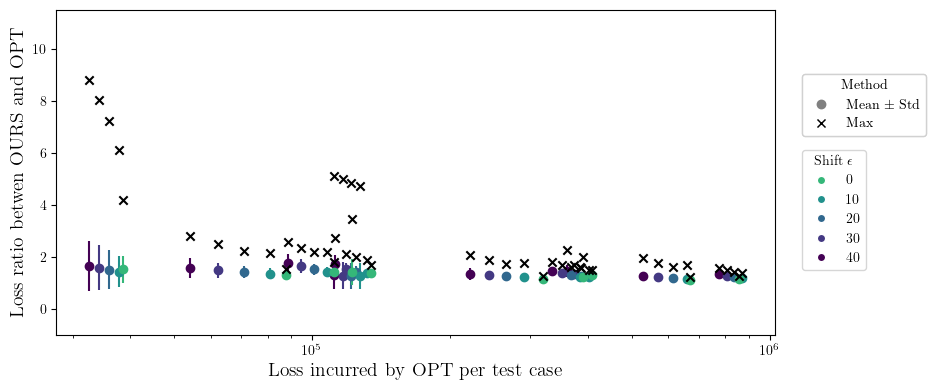

In [49]:
import itertools
from matplotlib.lines import Line2D
import matplotlib.cm as cm
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Linux Libertine'] + plt.rcParams['font.serif']

prod = itertools.product([2,2.5,3,3.5,4], offset_vals, [0]) #[40,30,20,10,0])
method_colors = {"OURS": "green", "DEC": "black"}
skew_values = [0, 10, 20, 30, 40]

# 1. Pick a colormap (e.g., 'viridis', 'plasma', 'coolwarm', or 'YlGnBu')
cmap = cm.get_cmap('viridis')

# 2. Normalize the values to [0, 1] so they can index the colormap
# This maps 0 -> 0.0 and 40 -> 1.0
norm = plt.Normalize(vmin=min(skew_values), vmax=1.5*max(skew_values))

# 3. Create the dictionary using a comprehension
test_skew_mag_colors = {val: cmap(norm(40-val)) for val in skew_values}

mean_opt_vals = []
ratio_vals = []
fig, axs = plt.subplots(1, figsize=(8,4))
smallest = 1000
identity = torch.logspace(3,6,101)

Y_LIMIT = 9.5

# Initialize lists


# Define your cutoff
Y_LIMIT = 10

min_opt = 2.3e4
max_opt = 1e7

directions = [1, 0, 0, 1, 1]
idx = 0
for test_skew_mag in [40,30,20,10,0]:
    all_mean_opt = []
    all_mean_our_gap = []
    all_std_our_gap = []
    normal_max_x = []
    normal_max_y = []
    for ps, offset in itertools.product([2,2.5,3,3.5,4], offset_vals):
        data = results[(ps, offset, test_skew_mag)]

        # Extract values (using .item() for clean floats)
        m_opt = data["mean_opt"].item()
        m_gap = data["mean_our_gap"].item()
        s_gap = data["std_our_gap"].item()
        mx_gap = data["max_our_gap"].item()

        if m_opt > min_opt and m_opt < max_opt:

            # 1. Store main data for the big batch plot
            all_mean_opt.append(m_opt)
            all_mean_our_gap.append(m_gap)
            all_std_our_gap.append(s_gap)

            # 2. Sort the "Max" points: List vs. Immediate Annotation
            if mx_gap < Y_LIMIT:
                # If it fits, save it to the list to scatter later
                normal_max_x.append(m_opt)
                normal_max_y.append(mx_gap)
            else:
                # If it's an outlier, plot the annotation immediately
                # (Annotations can't be batched easily)
                # axs.annotate('', xy=(m_opt, Y_LIMIT), xytext=(m_opt, Y_LIMIT - 1.0),
                #              arrowprops=dict(facecolor='red', edgecolor='red', arrowstyle='->', lw=2))
                direction = directions[idx]
                idx += 1
                if direction == 0:
                    if idx == 2: 
                        axs.text(m_opt * 0.997, Y_LIMIT + 0.7, f'{mx_gap:.1f}',
                                color='red', fontweight='bold', ha='center', va='top',
                                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
                    else:
                        axs.text(m_opt * 1.003, Y_LIMIT + 0.7, f'{mx_gap:.1f}',
                                color='red', fontweight='bold', ha='center', va='top',
                                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
                else:
                    axs.text(m_opt, Y_LIMIT - 0.3, f'{mx_gap:.1f}',
                            color='red', fontweight='bold', ha='center', va='top',
                            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
                axs.scatter(m_opt, Y_LIMIT, color='red', marker='x')

    # 3. Plot all means and error bars at once
    axs.errorbar(all_mean_opt, all_mean_our_gap, all_std_our_gap,
                fmt="o", c=test_skew_mag_colors[test_skew_mag], label="Mean $\pm$ Std", zorder=1)

    # 4. Plot all "normal" max points at once
    axs.scatter(normal_max_x, normal_max_y, c="black", marker="x",label="Max", zorder=2)

# 5. Lock the Y-axis
axs.set_ylim(-1, Y_LIMIT + 1.5)
axs.set_xscale("log")
h_mean = Line2D([0], [0], marker='o', color='w', 
                markerfacecolor='gray', markeredgecolor='gray', 
                linestyle='none', label=r"Mean $\pm$ Std")

# 2. "Max": 'X' with black edge (this was the invisible one)
h_max  = Line2D([0], [0], marker='x', color='w', 
                markeredgecolor='black',  # <--- THIS FIXES THE INVISIBLE X
                linestyle='none', label="Max")
method_handles = [h_mean, h_max]
leg1 = fig.legend(handles=method_handles, title="Method", loc='upper left', bbox_to_anchor=(1, 0.82), fontsize=10)
fig.add_artist(leg1)
shift_handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c,
                         linestyle='none', label=f'{k}%') for k, c in test_skew_mag_colors.items()]
fig.legend(handles=shift_handles, title=r"Shift $\epsilon$", loc='upper left', bbox_to_anchor=(1, 0.63), fontsize=10)
# Optional: Add legend
# axs.legend(loc='upper right')
axs.set_xlabel("Loss incurred by OPT per test case", fontsize=14)
axs.set_ylabel("Loss ratio betwen OURS and OPT", fontsize=14)
fig.tight_layout()
fig.savefig("Experiment results 2 appendix 2.png", dpi=500, bbox_inches='tight')

/var/folders/zy/zj7yfclj58z15k6w7zfrbtp40000gn/T/ipykernel_8885/3865428262.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')


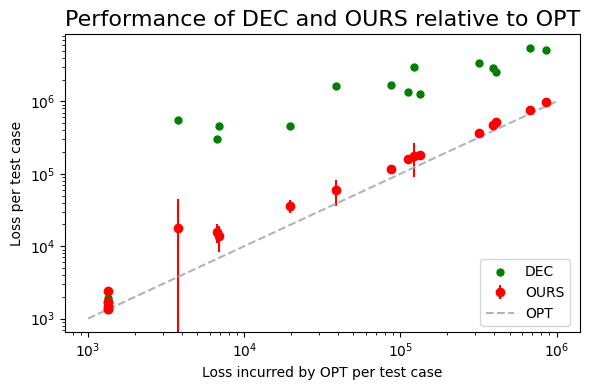

In [40]:
import itertools
from matplotlib.lines import Line2D
import matplotlib.cm as cm
plt.rcParams['text.usetex'] = False

prod = itertools.product([2,2.5,3,3.5,4], offset_vals, [0]) #[40,30,20,10,0])
method_colors = {"OURS": "green", "DEC": "black"}
skew_values = [0, 10, 20, 30, 40]

# 1. Pick a colormap (e.g., 'viridis', 'plasma', 'coolwarm', or 'YlGnBu')
cmap = cm.get_cmap('viridis') 

# 2. Normalize the values to [0, 1] so they can index the colormap
# This maps 0 -> 0.0 and 40 -> 1.0
norm = plt.Normalize(vmin=min(skew_values), vmax=1.5*max(skew_values))

# 3. Create the dictionary using a comprehension
test_skew_mag_colors = {val: cmap(norm(val)) for val in skew_values}

mean_opt_vals = []
ratio_vals = []
fig, axs = plt.subplots(1, figsize=(6,4))
smallest = 1000
identity = torch.logspace(3,6,101)

Y_LIMIT = 9.5

all_mean_opt = list()
all_mean_ours = list()
all_std_ours = list()
all_mean_dec = list()

for ps, offset, test_skew_mag in prod:
    data = results[(ps,offset,test_skew_mag)]
    mean_ours = data["mean_ours"]
    std_ours = data["std_ours"]
    mean_opt = data["mean_opt"]
    mean_dec = data["mean_dec"]

    all_mean_opt.append(mean_opt.item())
    all_mean_ours.append(mean_ours.item())
    all_std_ours.append(std_ours.item())
    all_mean_dec.append(mean_dec.item())

axs.scatter(all_mean_opt, all_mean_dec, c="green", s=25, label="DEC")
axs.errorbar(all_mean_opt, all_mean_ours, all_std_ours, fmt="o", c="red", label="OURS")
axs.plot(identity, identity, linestyle="--", label="OPT", color=(0.7, 0.7, 0.7))
handles, labels = axs.get_legend_handles_labels()

# 2. Define your desired order (by label name)
# This is an example; adjust the strings to match your labels exactly
desired_order = ['DEC', 'OURS', 'OPT']

# 3. Create a dictionary to map labels to handles for easy lookup
handle_dict = dict(zip(labels, handles))

# 4. Rebuild the lists in the new order
ordered_handles = [handle_dict[l] for l in desired_order if l in handle_dict]
ordered_labels = [l for l in desired_order if l in handle_dict]
axs.set_xscale('log')
axs.set_yscale('log')
axs.set_title("Performance of DEC and OURS relative to OPT", fontsize=16)
axs.set_xlabel("Loss incurred by OPT per test case")
axs.set_ylabel("Loss per test case")
# 1. Get current handles and labels from the axis

# 5. Re-apply the legend
axs.legend(ordered_handles, ordered_labels, loc='lower right', 
    bbox_to_anchor=(0.98, 0.02), # Coordinates are (x, y) from 0 to 1
    borderaxespad=0,
    facecolor='white')

fig.tight_layout()
fig.savefig("Experiment results 1.png", dpi=500, bbox_inches='tight')

In [25]:
handles, labels

([<matplotlib.collections.PathCollection at 0x147eb3260>,
  <ErrorbarContainer object of 3 artists>],
 ['DEC', 'OPT', 'OURS'])

/var/folders/zy/zj7yfclj58z15k6w7zfrbtp40000gn/T/ipykernel_8885/2964927679.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')
/var/folders/zy/zj7yfclj58z15k6w7zfrbtp40000gn/T/ipykernel_8885/2964927679.py:40: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axs[0].scatter(mean_opt * torch.ones(1), mean_dec * torch.ones(1), c=test_skew_mag_colors[test_skew_mag], marker=method_markers["DEC"], s=25)


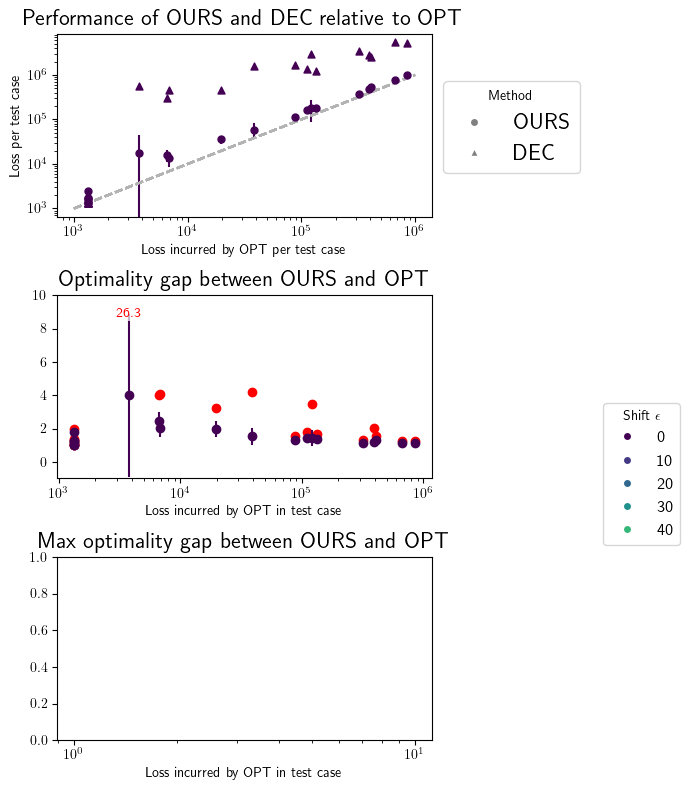

In [41]:
import itertools
from matplotlib.lines import Line2D
import matplotlib.cm as cm
plt.rcParams['text.usetex'] = True

prod = itertools.product([2,2.5,3,3.5,4], offset_vals, [0]) #[40,30,20,10,0])
method_markers = {r"OURS": "o", "DEC": "^"}
skew_values = [0, 10, 20, 30, 40]

# 1. Pick a colormap (e.g., 'viridis', 'plasma', 'coolwarm', or 'YlGnBu')
cmap = cm.get_cmap('viridis') 

# 2. Normalize the values to [0, 1] so they can index the colormap
# This maps 0 -> 0.0 and 40 -> 1.0
norm = plt.Normalize(vmin=min(skew_values), vmax=1.5*max(skew_values))

# 3. Create the dictionary using a comprehension
test_skew_mag_colors = {val: cmap(norm(val)) for val in skew_values}

mean_opt_vals = []
ratio_vals = []
fig, axs = plt.subplots(3, figsize=(6,8))
smallest = 1000
identity = torch.logspace(3,6,101)

Y_LIMIT = 9.5
for ps, offset, test_skew_mag in prod:
    data = results[(ps,offset,test_skew_mag)]
    mean_ours = data["mean_ours"]
    std_ours = data["std_ours"]
    mean_opt = data["mean_opt"]
    mean_dec = data["mean_dec"]
    # our_gap = data["our_gap"]
    mean_our_gap = data["mean_our_gap"]
    std_our_gap = data["std_our_gap"]
    max_our_gap = data["max_our_gap"]

    # if max_our_gap < 100:

    axs[0].scatter(mean_opt * torch.ones(1), mean_dec * torch.ones(1), c=test_skew_mag_colors[test_skew_mag], marker=method_markers["DEC"], s=25)
    axs[0].errorbar(mean_opt * torch.ones(1), mean_ours * torch.ones(1), std_ours * torch.ones(1), c=test_skew_mag_colors[test_skew_mag], marker=method_markers["OURS"], ms=5)
    axs[0].plot(identity, identity, linestyle="--", label="Optimal", color=(0.7, 0.7, 0.7))
    axs[1].errorbar(mean_opt * torch.ones(1), mean_our_gap * torch.ones(1), std_our_gap, c=test_skew_mag_colors[test_skew_mag], marker=method_markers["OURS"])
    if max_our_gap < 10:
        axs[1].scatter(mean_opt * torch.ones(1), max_our_gap * torch.ones(1), c="red", marker=method_markers["OURS"])
    else:
        # 2. Add text label indicating the actual value
        axs[1].text(mean_opt, Y_LIMIT - 0.2, f'{max_our_gap:.1f}', 
                    color='red', fontweight='bold', ha='center', va='top',
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].set_title("Performance of OURS and DEC relative to OPT", fontsize=16)
axs[0].set_xlabel("Loss incurred by OPT per test case")
axs[0].set_ylabel("Loss per test case")
axs[1].set_xscale('log')
axs[1].set_title("Optimality gap between OURS and OPT", fontsize=16)
axs[1].set_xlabel("Loss incurred by OPT in test case")
axs[1].set_ylim(-1,Y_LIMIT+0.5)
axs[2].set_xscale('log')
axs[2].set_title("Max optimality gap between OURS and OPT", fontsize=16)
axs[2].set_xlabel("Loss incurred by OPT in test case")
ps_handles = [Line2D([0], [0], marker=m, color='w', markerfacecolor='gray', 
                     linestyle='none', label=f'{k}') for k, m in method_markers.items()]

# 4. Create legend handles for "offset" (fixed marker, different colors)

axs[0].legend(handles=ps_handles, title="Method", loc='upper left', bbox_to_anchor=(1, 0.8), fontsize=16)
# .add_artist(leg1) # Vital: keeps leg1 visible when adding leg2
tsm_handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c, 
                         linestyle='none', label=f'{k}%') for k, c in test_skew_mag_colors.items()]
# Second legend: "offset"
fig.legend(handles=tsm_handles, title=r"Shift $\epsilon$", loc='upper left', bbox_to_anchor=(1, 0.5), fontsize=12)
# fig.suptitle("Performance , distribution radius 0.2")
fig.tight_layout()
fig.savefig("Experiment results.png", dpi=500, bbox_inches='tight')

dict_keys(['ps', 'offset', 'epochs', 'lr', 'torch_seed', 'radius', 'perform_tests', 'job_id', 'line_max_changes', 'line_min_changes', 'total_losses_per_iter', 'total_econ_losses_per_iter', 'total_viol_losses_per_iter', 'total_train_losses_per_iter', 'run_failed', 'fail_message', 'all_train_traj', (4, 'ours')])


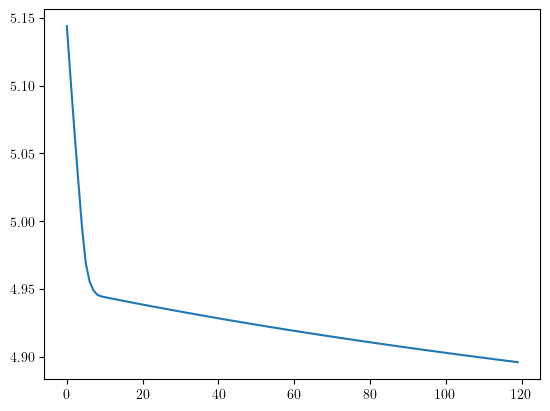

In [45]:
ckpt = torch.load("1a/checkpoint_ps3_offset0_epochs120_lr0.0001_torch_seed4_radius0.2_perform_testsTrue.pt")
print(ckpt.keys())
plt.plot(torch.log10(torch.sum(ckpt['total_losses_per_iter'],dim=1)))

3 0 10 2
3 0 10 2
3 0 20 2
3 0 20 2
3 0 30 2
3 0 30 2
3 0 40 2
3 0 40 2


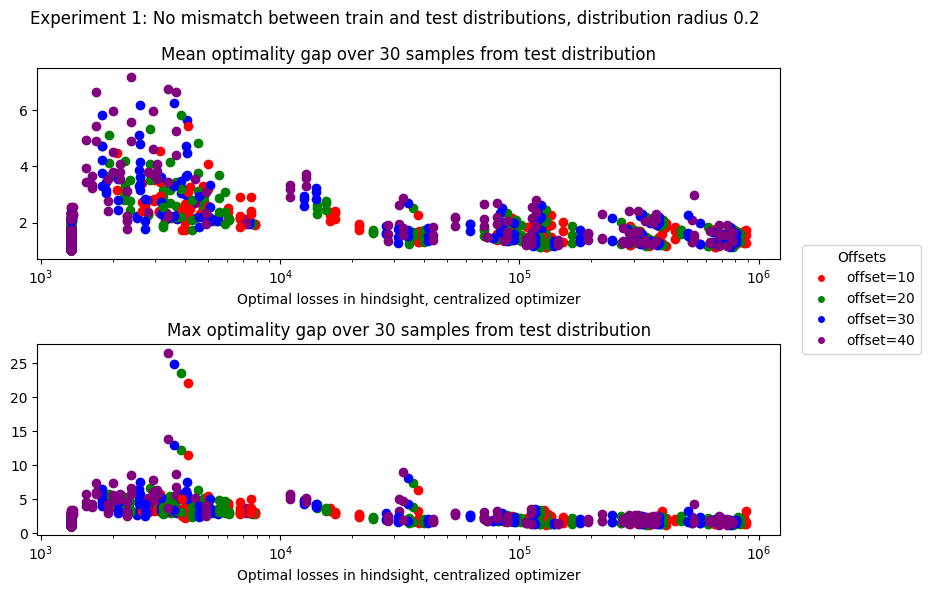

In [ ]:
import itertools
from matplotlib.lines import Line2D

prod = itertools.product(ps_vals, offset_vals, test_skew_mags, test_seeds)
test_skew_mag_colors = {10: 'red', 20: 'green', 30: 'blue', 40: "purple"}
mean_opt_vals = []
ratio_vals = []
fig, axs = plt.subplots(2, figsize=(8,6))
for ps, offset, test_skew_mag, test_seed in prod:
    for train_seed in [torch_seeds]:
        optimal_losses = opt_losses_dict[(ps,offset,test_skew_mag,test_seed)]
        dec_losses = dec_losses_dict[(ps,offset,test_skew_mag,test_seed)]
        our_losses = our_losses_dict[(ps,offset,test_skew_mag,train_seed,test_seed)]

        mean_opt = torch.mean(optimal_losses)
        
        our_gap = our_losses / optimal_losses
        dec_gap = dec_losses / optimal_losses

        mean_opt_vals.append(mean_opt)
        ratio_vals.append((ps, offset, test_skew_mag, test_seed, dec_losses / our_losses))

        axs[0].scatter(mean_opt * torch.ones(1), torch.mean(our_gap) * torch.ones(1), c=test_skew_mag_colors[test_skew_mag])
        axs[0].set_xscale('log')
        axs[0].set_title("Mean optimality gap over 30 samples from test distribution")
        axs[0].set_xlabel("Optimal losses in hindsight, centralized optimizer")
        if torch.max(our_gap) > 10:
            print(ps, offset, test_skew_mag, test_seed)
        axs[1].scatter(mean_opt * torch.ones(1), torch.max(our_gap) * torch.ones(1), c=test_skew_mag_colors[test_skew_mag])
        axs[1].set_title("Max losses")
        axs[1].set_xscale('log')
        axs[1].set_title("Max optimality gap over 30 samples from test distribution")
        axs[1].set_xlabel("Optimal losses in hindsight, centralized optimizer")

# 4. Create legend handles for "offset" (fixed marker, different colors)
tsm_handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c, 
                         linestyle='none', label=f'offset={k}') for k, c in test_skew_mag_colors.items()]

# Second legend: "offset"
fig.legend(handles=tsm_handles, title="Offsets", loc='upper left', bbox_to_anchor=(1, 0.6))
fig.suptitle("Experiment 1: No mismatch between train and test distributions, distribution radius 0.2")
fig.tight_layout()
fig.tight_layout()

tensor([4172.5920, 2810.1035, 3375.8173, 3703.0368, 3341.3865, 3710.2286,
        6474.7273, 3531.1537, 7348.0337, 2715.3505]) tensor(7904.3157)


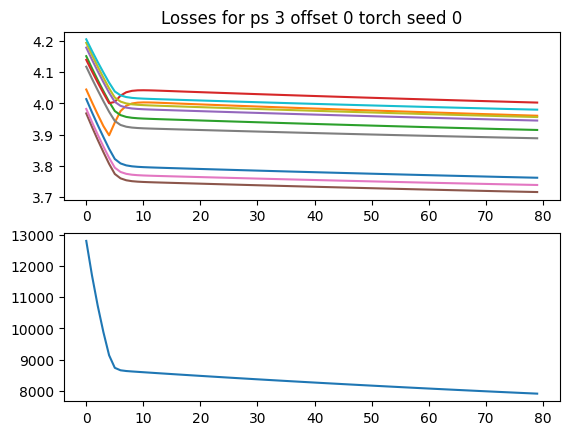

In [50]:
ps = 3
offset = 0
torch_seed = 0
epochs = 80
lr = 1e-4
# ckpt = torch.load(f"2a/checkpoint_ps{ps}_offset{offset}_epochs80_lr0.0001_torch_seed{torch_seed}_radius0.2_perform_testsFalse.pt")
ckpt = torch.load(f"2a/checkpoint_ps{ps}_offset{offset}_epochs{epochs}_lr{lr}_torch_seed{torch_seed}_radius0.2_perform_testsTrue.pt")
total_losses = ckpt["total_losses_per_iter"]

fig, axs = plt.subplots(2)
for i in range(10):
    axs[0].plot(torch.log10(total_losses[:,i]))
axs[0].set_title(f"Losses for ps {ps} offset {offset} torch seed {torch_seed}")
axs[1].plot(torch.sum(total_losses,dim=1)/10)
test_seed = 2
test_skew_mag = 10
print(opt_losses_dict[(ps,offset,test_skew_mag,test_seed)], torch.mean(total_losses[-1]))

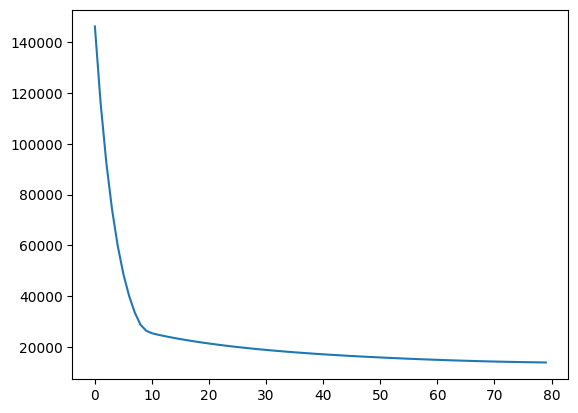

In [ ]:
python paper_experiments/2_yes_mismatch.py --torch_seed 0 --ps 2.0 --offset 0 --epochs 10 --radius 0.2 --perform_tests False --lr 1e-4

In [76]:
total_losses

tensor([[10325.3670, 11081.0271, 14167.8724, 13787.9830, 15090.9258,  9291.9835,
          9601.5129, 13110.3520, 15631.2248, 16042.6003],
        [ 4108.3586, 73521.6108,  5235.1594, 66755.9428, 21490.4519, 24262.0999,
         31325.2930, 40877.6292, 37596.0250, 20235.0050],
        [40725.5241, 41527.3313, 50048.3433, 46671.0470, 51809.2732, 37264.4424,
         37644.6386, 45893.0264, 53613.7606, 53330.9510],
        [ 5766.1151, 10158.7218,  8186.8824, 10891.6801,  8776.8269,  5188.3054,
          5465.4102,  7719.5558,  9005.0626,  9523.7633],
        [ 6496.9377,  7278.9780,  9139.3558,  9219.3196,  9775.3102,  5862.4817,
          6156.3092,  8598.8523, 10028.9420, 10562.6071],
        [ 3606.7739, 74040.4779,  4978.9767, 65691.0838, 18705.3121, 21274.3275,
         27886.1802, 38417.0459, 34334.1295, 17571.9378],
        [37738.6233, 38666.4046, 46402.5494, 43694.1909, 48129.7837, 34654.3751,
         35060.6177, 42838.6902, 49679.0489, 49672.1207],
        [ 6451.4639,  7092.

In [54]:
opt_losses_dict.keys()

dict_keys([(2, 0, 10, 0), (2, 0, 10, 1), (2, 0, 10, 2), (2, 0, 20, 0), (2, 0, 20, 1), (2, 0, 20, 2), (2, 0, 30, 0), (2, 0, 30, 1), (2, 0, 30, 2), (2, 0, 40, 0), (2, 0, 40, 1), (2, 0, 40, 2), (2, 60, 10, 0), (2, 60, 10, 1), (2, 60, 10, 2), (2, 60, 20, 0), (2, 60, 20, 1), (2, 60, 20, 2), (2, 60, 30, 0), (2, 60, 30, 1), (2, 60, 30, 2), (2, 60, 40, 0), (2, 60, 40, 1), (2, 60, 40, 2), (2, 120, 10, 0), (2, 120, 10, 1), (2, 120, 10, 2), (2, 120, 20, 0), (2, 120, 20, 1), (2, 120, 20, 2), (2, 120, 30, 0), (2, 120, 30, 1), (2, 120, 30, 2), (2, 120, 40, 0), (2, 120, 40, 1), (2, 120, 40, 2), (2, 180, 10, 0), (2, 180, 10, 1), (2, 180, 10, 2), (2, 180, 20, 0), (2, 180, 20, 1), (2, 180, 20, 2), (2, 180, 30, 0), (2, 180, 30, 1), (2, 180, 30, 2), (2, 180, 40, 0), (2, 180, 40, 1), (2, 180, 40, 2), (2.5, 0, 10, 0), (2.5, 0, 10, 1), (2.5, 0, 10, 2), (2.5, 0, 20, 0), (2.5, 0, 20, 1), (2.5, 0, 20, 2), (2.5, 0, 30, 0), (2.5, 0, 30, 1), (2.5, 0, 30, 2), (2.5, 0, 40, 0), (2.5, 0, 40, 1), (2.5, 0, 40, 2), (2.5,

In [77]:
for key in opt_losses_dict.keys():
    ps = key[0]
    offset = key[1]
    tsm = key[2]
    test_seed = key[3]
    if ps == 3 and offset == 0:
        print(f"tsm {tsm} test_seed {test_seed} mean opt loss {torch.mean(opt_losses_dict[key])}")

tsm 10 test_seed 0 mean opt loss 3883.145060482703
tsm 10 test_seed 1 mean opt loss 3988.437605484324
tsm 10 test_seed 2 mean opt loss 4118.242993094
tsm 20 test_seed 0 mean opt loss 3245.558808965463
tsm 20 test_seed 1 mean opt loss 4265.131424193083
tsm 20 test_seed 2 mean opt loss 3849.927295309608
tsm 30 test_seed 0 mean opt loss 2716.7215237601476
tsm 30 test_seed 1 mean opt loss 4564.3245795671155
tsm 30 test_seed 2 mean opt loss 3606.3192898115653
tsm 40 test_seed 0 mean opt loss 2289.8294845307523
tsm 40 test_seed 1 mean opt loss 4885.407774721224
tsm 40 test_seed 2 mean opt loss 3387.1228297072303


In [65]:
for key in our_losses_dict.keys():
    ps = key[0]
    offset = key[1]
    tsm = key[2]
    train_seed = key[3]
    test_seed = key[4]
    if ps == 2 and offset == 60:
        print(f"tsm {tsm} train_seed {train_seed} test_seed {test_seed} mean opt loss {torch.mean(our_losses_dict[key])}")

tsm 10 train_seed 0 test_seed 0 mean opt loss 1487.2768829118802
tsm 10 train_seed 0 test_seed 1 mean opt loss 1489.7601566420476
tsm 10 train_seed 0 test_seed 2 mean opt loss 1484.7095669708747
tsm 10 train_seed 1 test_seed 0 mean opt loss 1485.6114158002688
tsm 10 train_seed 1 test_seed 1 mean opt loss 1487.1030950224012
tsm 10 train_seed 1 test_seed 2 mean opt loss 1484.8492417234197
tsm 10 train_seed 2 test_seed 0 mean opt loss 1486.9324024463829
tsm 10 train_seed 2 test_seed 1 mean opt loss 1489.0852216730473
tsm 10 train_seed 2 test_seed 2 mean opt loss 1484.681123418587
tsm 20 train_seed 0 test_seed 0 mean opt loss 1485.3678140369313
tsm 20 train_seed 0 test_seed 1 mean opt loss 1491.232901671489
tsm 20 train_seed 0 test_seed 2 mean opt loss 1483.831532747684
tsm 20 train_seed 1 test_seed 0 mean opt loss 1484.9748492386275
tsm 20 train_seed 1 test_seed 1 mean opt loss 1487.5528463741182
tsm 20 train_seed 1 test_seed 2 mean opt loss 1482.2190454336028
tsm 20 train_seed 2 test_see

In [57]:
our_losses_dict.keys()

dict_keys([(2, 0, 10, 0, 0), (2, 0, 10, 0, 1), (2, 0, 10, 0, 2), (2, 0, 10, 1, 0), (2, 0, 10, 1, 1), (2, 0, 10, 1, 2), (2, 0, 10, 2, 0), (2, 0, 10, 2, 1), (2, 0, 10, 2, 2), (2, 0, 20, 0, 0), (2, 0, 20, 0, 1), (2, 0, 20, 0, 2), (2, 0, 20, 1, 0), (2, 0, 20, 1, 1), (2, 0, 20, 1, 2), (2, 0, 20, 2, 0), (2, 0, 20, 2, 1), (2, 0, 20, 2, 2), (2, 0, 30, 0, 0), (2, 0, 30, 0, 1), (2, 0, 30, 0, 2), (2, 0, 30, 1, 0), (2, 0, 30, 1, 1), (2, 0, 30, 1, 2), (2, 0, 30, 2, 0), (2, 0, 30, 2, 1), (2, 0, 30, 2, 2), (2, 0, 40, 0, 0), (2, 0, 40, 0, 1), (2, 0, 40, 0, 2), (2, 0, 40, 1, 0), (2, 0, 40, 1, 1), (2, 0, 40, 1, 2), (2, 0, 40, 2, 0), (2, 0, 40, 2, 1), (2, 0, 40, 2, 2), (2, 60, 10, 0, 0), (2, 60, 10, 0, 1), (2, 60, 10, 0, 2), (2, 60, 10, 1, 0), (2, 60, 10, 1, 1), (2, 60, 10, 1, 2), (2, 60, 10, 2, 0), (2, 60, 10, 2, 1), (2, 60, 10, 2, 2), (2, 60, 20, 0, 0), (2, 60, 20, 0, 1), (2, 60, 20, 0, 2), (2, 60, 20, 1, 0), (2, 60, 20, 1, 1), (2, 60, 20, 1, 2), (2, 60, 20, 2, 0), (2, 60, 20, 2, 1), (2, 60, 20, 2, 2),

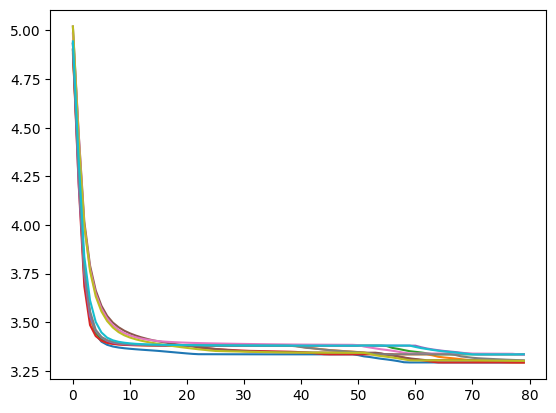

In [35]:
ckpt = torch.load("8365970/checkpoint_ps3_offset180_epochs80_lr0.001_torch_seed2_radius0.2_perform_testsTrue.pt")
total_losses = ckpt["total_losses_per_iter"]

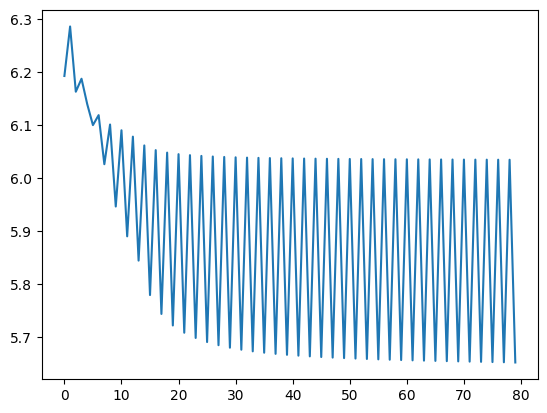

In [ ]:
plt.plot(torch.log10(torch.sum(total_losses,dim=1)))
plt

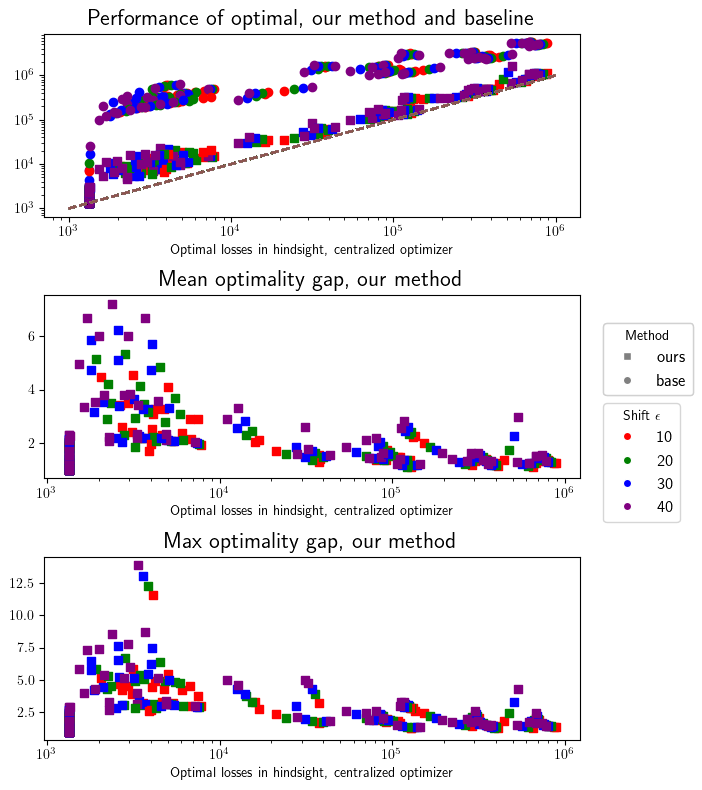

In [ ]:
import itertools
from matplotlib.lines import Line2D
plt.rcParams['text.usetex'] = True

prod = itertools.product(ps_vals, offset_vals, test_skew_mags, test_seeds)
method_markers = {"ours": "s", "dec": "o"}
test_skew_mag_colors = {10: 'red', 20: 'green', 30: 'blue', 40: "purple"}

mean_opt_vals = []
ratio_vals = []
fig, axs = plt.subplots(3, figsize=(6,8))
smallest = 1000
identity = torch.logspace(3,6,101)
for ps, offset, test_skew_mag, test_seed in prod:
    for train_seed in [0]: # torch_seeds:
        optimal_losses = opt_losses_dict[(ps,offset,test_skew_mag,test_seed)]
        dec_losses = dec_losses_dict[(ps,offset,test_skew_mag,test_seed)]
        our_losses = our_losses_dict[(ps,offset,test_skew_mag,train_seed,test_seed)]

        mean_opt = torch.mean(optimal_losses)
        
        our_gap = our_losses / optimal_losses
        dec_gap = dec_losses / optimal_losses

        mean_opt_vals.append(mean_opt)

        axs[0].scatter(mean_opt * torch.ones(1), torch.mean(dec_losses) * torch.ones(1), c=test_skew_mag_colors[test_skew_mag], marker=method_markers["dec"])
        axs[0].scatter(mean_opt * torch.ones(1), torch.mean(our_losses) * torch.ones(1), c=test_skew_mag_colors[test_skew_mag], marker=method_markers["ours"])
        axs[0].plot(identity, identity, linestyle="--", label="Optimal")
        axs[1].scatter(mean_opt * torch.ones(1), torch.mean(our_gap) * torch.ones(1), c=test_skew_mag_colors[test_skew_mag], marker=method_markers["ours"])
        axs[2].scatter(mean_opt * torch.ones(1), torch.max(our_gap) * torch.ones(1), c=test_skew_mag_colors[test_skew_mag], marker=method_markers["ours"])

axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].set_title("Performance of optimal, our method and decentralized", fontsize=16)
axs[0].set_xlabel("Optimal losses in hindsight, centralized optimizer")
axs[1].set_xscale('log')
axs[1].set_title("Mean optimality gap, our method", fontsize=16)
axs[1].set_xlabel("Optimal losses in hindsight, centralized optimizer")
axs[2].set_xscale('log')
axs[2].set_title("Max optimality gap, our method", fontsize=16)
axs[2].set_xlabel("Optimal losses in hindsight, centralized optimizer")
ps_handles = [Line2D([0], [0], marker=m, color='w', markerfacecolor='gray', 
                     linestyle='none', label=f'{k}') for k, m in method_markers.items()]

# 4. Create legend handles for "offset" (fixed marker, different colors)

leg1 = fig.legend(handles=ps_handles, title="Method", loc='upper left', bbox_to_anchor=(1, 0.6), fontsize=12)
fig.add_artist(leg1) # Vital: keeps leg1 visible when adding leg2
tsm_handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c, 
                         linestyle='none', label=f'{k}%') for k, c in test_skew_mag_colors.items()]
# Second legend: "offset"
fig.legend(handles=tsm_handles, title=r"Shift $\epsilon$", loc='upper left', bbox_to_anchor=(1, 0.5), fontsize=12)
# fig.suptitle("Performance , distribution radius 0.2")
fig.tight_layout()
fig.savefig("Experiment results.png", dpi=500, bbox_inches='tight')

In [45]:
smallest

tensor(5.6324)

In [91]:
ratio_vals

[(2,
  0,
  5,
  0,
  tensor([0.9810, 0.9913, 0.9872, 0.9856, 0.9939, 0.9899, 0.9881, 0.9821, 0.9858,
          0.9865, 0.9859, 0.9937, 0.9866, 0.9803, 0.9795, 0.9885, 0.9978, 0.9858,
          0.9920, 0.9910, 0.9901, 0.9920, 0.9897, 0.9916, 0.9759, 0.9888, 0.9945,
          0.9975, 0.9884, 0.9884]),
  tensor([1635.5214, 1635.5509, 1635.5972, 1635.6011, 1635.5112, 1635.5613,
          1635.6067, 1635.6133, 1635.6224, 1635.5429, 1635.5284, 1635.5283,
          1635.5467, 1635.6029, 1635.5831, 1635.5902, 1635.5481, 1635.5165,
          1635.5722, 1635.5975, 1635.5562, 1635.5473, 1635.5700, 1635.5271,
          1635.5779, 1635.5529, 1635.5757, 1635.6221, 1635.4910, 1635.5538]),
  tensor([1667.2449, 1649.8972, 1656.7389, 1659.5395, 1645.5526, 1652.2986,
          1655.3431, 1665.4280, 1659.2432, 1657.8683, 1658.9157, 1645.8641,
          1657.7498, 1668.3974, 1669.7823, 1654.6584, 1639.2110, 1659.0277,
          1648.7845, 1650.5130, 1651.9309, 1648.7963, 1652.5896, 1649.4287,
          16

In [ ]:
import itertools
from matplotlib.lines import Line2D

prod = itertools.product(ps_vals, offset_vals, test_skew_mags, test_seeds)
test_skew_mag_colors = {5: 'red', 10: 'green', 15: 'blue'}

fig, axs = plt.subplots(2, figsize=(8,6))
for ps, offset, test_skew_mag, test_seed in prod:
    for train_seed in torch_seeds:
        optimal_losses = opt_losses_dict[(ps,offset,test_skew_mag,test_seed)]
        dec_losses = dec_losses_dict[(ps,offset,test_skew_mag,test_seed)]
        our_losses = our_losses_dict[(ps,offset,test_skew_mag,train_seed,test_seed)]

        mean_opt = torch.mean(optimal_losses)
        our_gap = our_losses / optimal_losses
        dec_gap = dec_losses / optimal_losses

        axs[0].scatter(mean_opt * torch.ones(1), torch.mean(our_gap) * torch.ones(1), c=test_skew_mag_colors[test_skew_mag])
        axs[0].set_xscale('log')
        axs[0].set_title("Mean optimality gap over 30 samples from test distribution")
        axs[0].set_xlabel("Optimal losses in hindsight, centralized optimizer")
        axs[1].scatter(mean_opt * torch.ones(1), torch.max(our_gap) * torch.ones(1), c=test_skew_mag_colors[test_skew_mag])
        axs[1].set_title("Max losses")
        axs[1].set_xscale('log')
        axs[1].set_title("Max optimality gap over 30 samples from test distribution")
        axs[1].set_xlabel("Optimal losses in hindsight, centralized optimizer")
fig.tight_layout()

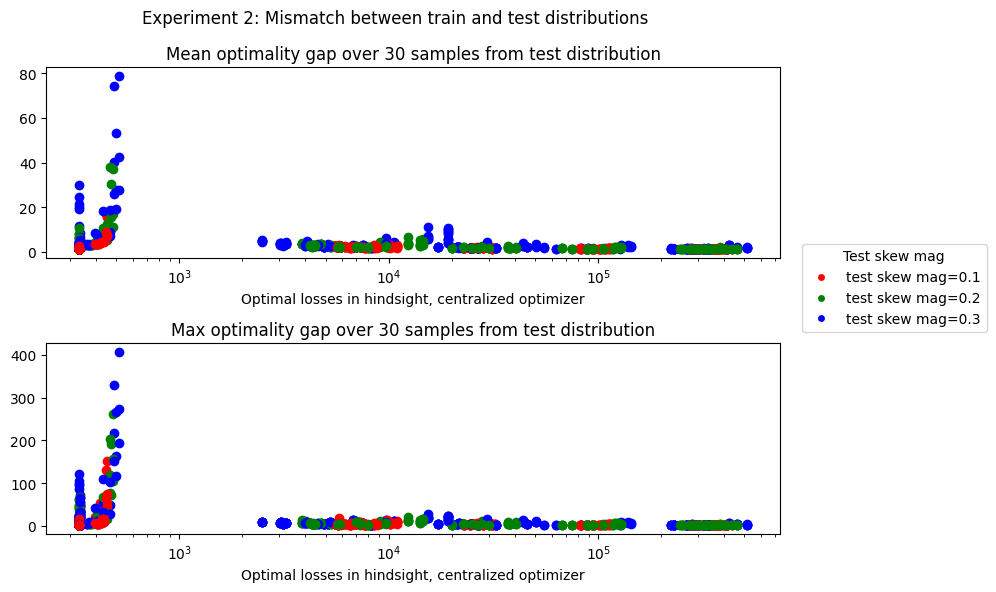

In [ ]:


# ps_markers = {1: 'o', 2: 's', 3: '^', 4: 'D'}      # o=circle, s=square, ^=triangle, D=diamond
# offset_colors = {0: 'red', 60: 'blue', 120: 'green', 180: 'orange'}
test_skew_mag_colors = {1: 'red', 2: 'green', 3: 'blue'}

fig, axs = plt.subplots(2, figsize=(8,6))
for key in all_results.keys():
    results = all_results[key]
    num_results = len(mean_vals)
    mean_vals = results["mean_vals"]
    max_vals = results["max_vals"]
    mol_vals = results["mol_vals"]
    ps = results["ps"]
    offset = results["offset"]
    test_skew_mag = results["test_skew_mag"]

    axs[0].scatter(mol_vals, mean_vals, c=test_skew_mag_colors[test_skew_mag])
    axs[0].set_xscale('log')
    axs[0].set_title("Mean optimality gap over 30 samples from test distribution")
    axs[0].set_xlabel("Optimal losses in hindsight, centralized optimizer")
    axs[1].scatter(mol_vals, max_vals, c=test_skew_mag_colors[test_skew_mag])
    axs[1].set_title("Max losses")
    axs[1].set_xscale('log')
    axs[1].set_title("Max optimality gap over 30 samples from test distribution")
    axs[1].set_xlabel("Optimal losses in hindsight, centralized optimizer")

# 1. Define your mappings

tsm_handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c, 
                           linestyle='none', label=f'test skew mag={k/10}') for k, c in test_skew_mag_colors.items()]
# ps_handles = [Line2D([0], [0], marker=m, color='w', markerfacecolor='gray', 
#                      linestyle='none', label=f'ps={k}') for k, m in ps_markers.items()]

# # 4. Create legend handles for "offset" (fixed marker, different colors)
# offset_handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c, 
#                          linestyle='none', label=f'offset={k}') for k, c in offset_colors.items()]
# leg1 = fig.legend(handles=ps_handles, title="PS Values", loc='upper left', bbox_to_anchor=(1, 0.8))
# fig.add_artist(leg1) # Vital: keeps leg1 visible when adding leg2

# # Second legend: "offset"
fig.legend(handles=tsm_handles, title="Test skew mag", loc='upper left', bbox_to_anchor=(1, 0.6))
fig.suptitle("Experiment 2: Mismatch between train and test distributions")
fig.tight_layout()

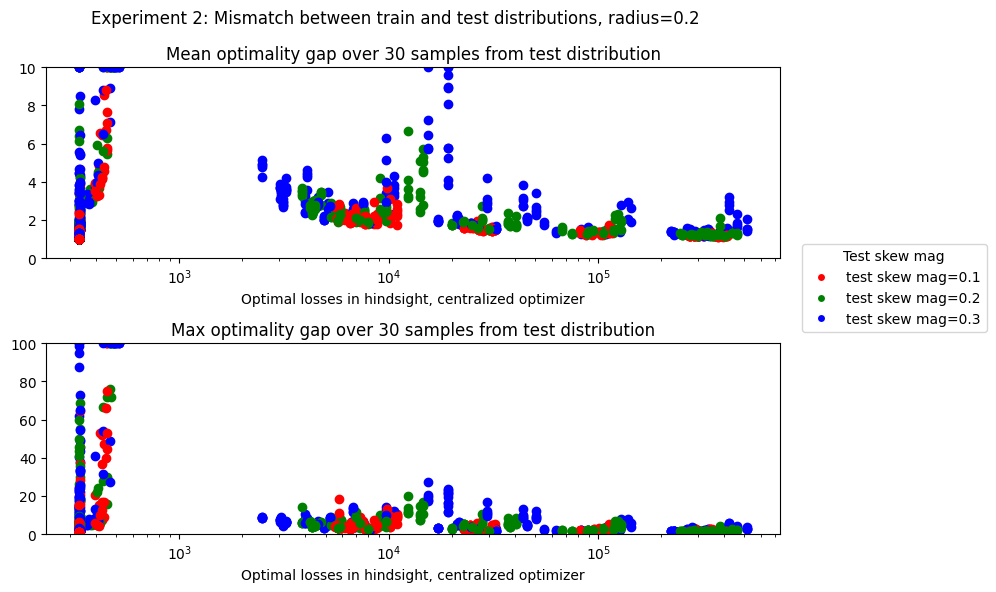

In [23]:
from matplotlib.lines import Line2D

# ps_markers = {1: 'o', 2: 's', 3: '^', 4: 'D'}      # o=circle, s=square, ^=triangle, D=diamond
# offset_colors = {0: 'red', 60: 'blue', 120: 'green', 180: 'orange'}
test_skew_mag_colors = {1: 'red', 2: 'green', 3: 'blue'}

radius = 0.2
fig, axs = plt.subplots(2, figsize=(8,6))
max_mean_lim = 10
max_max_lim = 100
for key in all_results.keys():
    results = all_results[key]
    num_results = len(mean_vals)
    mean_vals = torch.tensor(results["mean_vals"])
    max_vals = torch.tensor(results["max_vals"])
    mol_vals = torch.tensor(results["mol_vals"])
    ps = results["ps"]
    offset = results["offset"]
    test_skew_mag = results["test_skew_mag"]

    axs[0].scatter(mol_vals, torch.min(torch.tensor(max_mean_lim),mean_vals), c=test_skew_mag_colors[test_skew_mag])
    axs[0].set_xscale('log')
    axs[0].set_ylim(0,max_mean_lim)
    axs[0].set_title("Mean optimality gap over 30 samples from test distribution")
    axs[0].set_xlabel("Optimal losses in hindsight, centralized optimizer")
    axs[1].scatter(mol_vals, torch.min(torch.tensor(max_max_lim),max_vals), c=test_skew_mag_colors[test_skew_mag])
    axs[1].set_title("Max losses")
    axs[1].set_xscale('log')
    axs[1].set_ylim(0,max_max_lim)
    axs[1].set_title("Max optimality gap over 30 samples from test distribution")
    axs[1].set_xlabel("Optimal losses in hindsight, centralized optimizer")

# 1. Define your mappings

tsm_handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c, 
                           linestyle='none', label=f'test skew mag={k/10}') for k, c in test_skew_mag_colors.items()]
# ps_handles = [Line2D([0], [0], marker=m, color='w', markerfacecolor='gray', 
#                      linestyle='none', label=f'ps={k}') for k, m in ps_markers.items()]

# # 4. Create legend handles for "offset" (fixed marker, different colors)
# offset_handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c, 
#                          linestyle='none', label=f'offset={k}') for k, c in offset_colors.items()]
# leg1 = fig.legend(handles=ps_handles, title="PS Values", loc='upper left', bbox_to_anchor=(1, 0.8))
# fig.add_artist(leg1) # Vital: keeps leg1 visible when adding leg2

# # Second legend: "offset"
fig.legend(handles=tsm_handles, title="Test skew mag", loc='upper left', bbox_to_anchor=(1, 0.6))
fig.suptitle(f"Experiment 2: Mismatch between train and test distributions, radius={radius}")
fig.tight_layout()

In [ ]:
FOLDER_PATH = "7247557"
filename_pattern = re.compile(
    r"checkpoint_ps(\d+)_offset(\d+)_test_skew_mag(\d+)_epochs(\d+)_lr([\d\.]+)_torch_seed(\d+)\.pt"
)

if not os.path.exists(FOLDER_PATH):
    print(f"Error: Directory not found: {FOLDER_PATH}")

files = [f for f in os.listdir(FOLDER_PATH) if f.endswith(".pt")]
print(f"Total files found in directory {FOLDER_PATH}: {len(files)}")

opt_results = dict()
for filename in files:
    match = filename_pattern.search(filename)
    if match:
        # Extract values decd on the regex groups
        # The regex order is: ps, offset, skew, epochs, lr, seed
        ps = int(match.group(1))
        offset = int(match.group(2))
        test_skew = int(match.group(3))
        epochs = int(match.group(4))
        lr = float(match.group(5))
        torch_seed = int(match.group(6))

        opt_losses = torch.zeros(10,30)
        ckpt = torch.load(f"{FOLDER_PATH}/{filename}")
        for i in range(10):
            opt_losses[i] = ckpt[(i,"optimal")]
        opt_results[(torch_seed, ps, offset, test_skew)] = opt_losses

FOLDER_PATH = "7252848"
filename_pattern = re.compile(
    r"checkpoint_ps(\d+)_offset(\d+)_test_skew_mag(\d+)_epochs(\d+)_lr([\d\.]+)_torch_seed(\d+)\.pt"
)

if not os.path.exists(FOLDER_PATH):
    print(f"Error: Directory not found: {FOLDER_PATH}")

files = [f for f in os.listdir(FOLDER_PATH) if f.endswith(".pt")]
print(f"Total files found in directory {FOLDER_PATH}: {len(files)}")

for filename in files:
    match = filename_pattern.search(filename)
    if match:
        # Extract values decd on the regex groups
        # The regex order is: ps, offset, skew, epochs, lr, seed
        ps = int(match.group(1))
        offset = int(match.group(2))
        test_skew = int(match.group(3))
        epochs = int(match.group(4))
        lr = float(match.group(5))
        torch_seed = int(match.group(6))

        opt_losses = torch.zeros(10,30)
        ckpt = torch.load(f"{FOLDER_PATH}/{filename}")
        for i in range(10):
            opt_losses[i] = ckpt[(i,"optimal")]
        opt_results[(torch_seed, ps, offset, test_skew)] = opt_losses


Total files found in directory 7247557: 32
Total files found in directory 7252848: 12


In [65]:
len(all_results.keys())

245

In [64]:
for key in all_results.keys():
    print(key)

(7, 4, 120, 2)
(7, 2, 120, 3)
(4, 3, 120, 1)
(6, 3, 120, 3)
(5, 2, 120, 1)
(3, 1, 180, 2)
(6, 2, 0, 2)
(4, 1, 120, 2)
(4, 2, 60, 1)
(5, 3, 0, 1)
(3, 1, 0, 3)
(7, 4, 0, 2)
(4, 3, 60, 2)
(8, 4, 0, 1)
(7, 3, 0, 3)
(6, 2, 60, 3)
(3, 2, 120, 3)
(7, 1, 180, 2)
(8, 1, 180, 1)
(6, 2, 180, 1)
(7, 1, 0, 3)
(5, 4, 60, 2)
(8, 3, 180, 2)
(3, 3, 0, 3)
(5, 1, 0, 1)
(3, 4, 0, 2)
(6, 1, 60, 2)
(7, 3, 180, 1)
(4, 2, 180, 3)
(6, 1, 180, 2)
(3, 2, 0, 2)
(7, 2, 180, 1)
(4, 3, 180, 3)
(6, 1, 0, 3)
(8, 2, 180, 2)
(8, 4, 180, 3)
(8, 1, 60, 1)
(3, 2, 60, 3)
(4, 1, 0, 1)
(7, 1, 60, 2)
(5, 2, 180, 3)
(6, 2, 120, 3)
(5, 3, 120, 1)
(7, 3, 120, 3)
(4, 2, 120, 1)
(8, 2, 0, 1)
(7, 2, 0, 2)
(5, 1, 120, 2)
(5, 2, 60, 1)
(4, 3, 0, 1)
(8, 3, 60, 3)
(3, 2, 180, 1)
(6, 4, 0, 2)
(5, 3, 60, 2)
(3, 1, 60, 2)
(8, 1, 120, 3)
(7, 2, 60, 3)
(3, 2, 0, 1)
(6, 1, 180, 1)
(4, 1, 180, 3)
(8, 1, 60, 2)
(3, 1, 120, 3)
(6, 4, 60, 3)
(7, 1, 60, 1)
(4, 1, 0, 2)
(7, 4, 180, 3)
(3, 3, 60, 3)
(5, 1, 60, 3)
(7, 2, 180, 2)
(4, 4, 60, 1)
(8, 2, 

In [74]:
ratios = all_results[(3,3,60,2)] / opt_results[(1,3,60,2)]
torch.mean(ratios, dim=1)

tensor([1.9729, 2.0172, 2.7918, 2.2837, 1.8911, 2.7767, 4.5016, 2.4263, 2.0830,
        2.3973])

In [58]:
opt_results[(1,3,60,2)]

tensor([[ 4105.5080,  4590.7470, 10735.6595, 10016.9318,  7456.4969,  4580.9593,
          3004.1505,  2844.6419,  5447.5047,  8400.4465,  6000.0530,  2703.7643,
          6313.8923,  6955.8859,  6397.1262,  6027.4572,  5793.2276,  5320.5026,
          8191.8616,  4049.0303,  6066.0644,  3987.5846,  4823.7523,  6438.5991,
          6021.6716,  5276.0290,  5249.6125,  4290.8922,  4896.3035,  4980.0836],
        [ 7098.1955,  4267.9882,  6187.9283, 14546.9018,  3598.9719, 11805.7195,
          6760.9635,  6103.3461,  8786.5846, 11648.0931,  4199.3846,  7084.9534,
          8016.1859,  6176.9900,  8071.2203,  5715.1101,  6434.2042,  7185.6550,
          7253.7516,  5955.8474, 10246.3651,  3130.2691,  5113.1527,  5476.4149,
          6674.6944,  3621.0895, 11035.1697,  7223.6763,  6008.6024, 12288.7994],
        [ 4846.7766,  6023.5895,  1874.2250,  4919.3324,  4189.9303,  3781.2783,
          5334.1422,  5249.4969,  3891.3330,  4966.4902,  2552.5194,  1514.0007,
          5656.6284,  2803

In [57]:
for key in opt_results.keys():
    print(key)

(1, 1, 0, 1)
(1, 2, 120, 1)
(1, 3, 0, 1)
(1, 3, 120, 1)
(1, 1, 120, 2)
(1, 2, 60, 1)
(1, 3, 60, 2)
(1, 2, 180, 3)
(1, 3, 120, 2)
(1, 2, 0, 3)
(1, 3, 60, 1)
(1, 2, 60, 2)
(1, 1, 120, 1)
(1, 1, 60, 3)
(1, 1, 180, 3)
(1, 1, 0, 2)
(1, 2, 120, 2)
(1, 3, 0, 2)
(1, 1, 60, 1)
(1, 2, 180, 2)
(1, 2, 0, 1)
(1, 1, 120, 3)
(1, 3, 60, 3)
(1, 1, 180, 1)
(1, 2, 120, 3)
(1, 3, 0, 3)
(1, 1, 180, 2)
(1, 1, 0, 3)
(1, 2, 180, 1)
(1, 1, 60, 2)
(1, 2, 0, 2)
(1, 2, 60, 3)


In [12]:
ckpt["torch_seed"]

3

In [15]:
foo = ckpt[(3,0,"ours")]

In [16]:
foo

tensor([64053.9240, 36815.5053, 34715.6754, 37661.7271, 24117.6223, 25263.7348,
        32689.2427, 38134.7320, 38323.2936, 35278.5631, 29094.8852, 27849.9065,
        31220.5735, 35499.9252, 40050.2978, 32255.2904, 28713.0244, 30981.0363,
        37597.7444, 35162.2666, 28233.1615, 27358.7160, 31331.0362, 23290.7317,
        54818.9718, 35302.7955, 27553.1592, 33203.2826, 33347.4699, 32679.8293])